#### Aggregated weighted full-school network (static, weighted)  SocioPatterns High School (2013)

In [ ]:
# ============================================================
# Load Libraries
# ============================================================
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy import stats as scipy_stats
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# -----------------------------
# Paths (as uploaded)
# -----------------------------
CONTACTS_PATH = "High-School_data_2013.csv"
META_PATH     = "metadata_2013.txt"


In [ ]:
# -----------------------------
# 0) Load data
# -----------------------------
def load_contacts(path: str) -> pd.DataFrame:
    """
    Expected whitespace-separated columns:
    t i j class_i class_j
    """
    df = pd.read_csv(path, sep=r"\s+", header=None, names=["t", "i", "j", "class_i", "class_j"])
    df["i"] = df["i"].astype(int)
    df["j"] = df["j"].astype(int)
    return df

def load_metadata(path: str) -> pd.DataFrame:
    """
    Expected whitespace-separated columns:
    id class gender
    """
    meta = pd.read_csv(path, sep=r"\s+", header=None, names=["id", "class", "gender"])
    meta["id"] = meta["id"].astype(int)
    meta["class"] = meta["class"].astype(str)
    meta["gender"] = meta["gender"].astype(str)
    return meta

contacts = load_contacts(CONTACTS_PATH)
meta = load_metadata(META_PATH)

print("Contacts:", contacts.shape, "Metadata:", meta.shape)
print(contacts.head())
print(meta.head())

Contacts: (188508, 5) Metadata: (329, 3)
            t    i    j class_i class_j
0  1385982020  454  640      MP      MP
1  1385982020    1  939   2BIO3   2BIO3
2  1385982020  185  258     PC*     PC*
3  1385982020   55  170   2BIO3   2BIO3
4  1385982020    9  453      PC      PC
    id  class gender
0  650  2BIO1      F
1  498  2BIO1      F
2  627  2BIO1      F
3  857  2BIO1      F
4  487  2BIO1      F


In [ ]:
# -----------------------------
# 1) Build aggregated weighted graph
# -----------------------------
def aggregate_edges(contacts: pd.DataFrame, dt_seconds: int = 20) -> pd.DataFrame:
    """
    Aggregates pairwise contacts into undirected edges:
    - count: number of contact records
    - duration_s: count * dt_seconds
    """
    uv = np.sort(contacts[["i", "j"]].values, axis=1)
    tmp = contacts.copy()
    tmp["u"] = uv[:, 0]
    tmp["v"] = uv[:, 1]

    agg = tmp.groupby(["u", "v"]).size().reset_index(name="count")
    agg["duration_s"] = agg["count"] * dt_seconds
    return agg

edge_df = aggregate_edges(contacts, dt_seconds=20)
print("Aggregated edges:", edge_df.shape)
print(edge_df.head())

def build_graph(edge_df: pd.DataFrame, meta: pd.DataFrame) -> nx.Graph:
    """
    Graph edges contain:
    - count
    - duration_s
    We'll also prepare normalized weights:
    - w_count_norm
    - w_dur_norm
    Node attributes:
    - class
    - gender
    """
    G = nx.Graph()

    # add edges
    for _, r in edge_df.iterrows():
        u, v = int(r["u"]), int(r["v"])
        G.add_edge(
            u, v,
            count=float(r["count"]),
            duration_s=float(r["duration_s"]),
        )

    # node attributes from metadata
    mm = meta.set_index("id")[["class", "gender"]].to_dict(orient="index")
    for n in G.nodes():
        if n in mm:
            G.nodes[n]["class"] = mm[n]["class"]
            G.nodes[n]["gender"] = mm[n]["gender"]
        else:
            G.nodes[n]["class"] = "Unknown"
            G.nodes[n]["gender"] = "Unknown"

    # normalized edge weights (important for curvature + infection probs)
    counts = np.array([d["count"] for _, _, d in G.edges(data=True)], dtype=float)
    durs   = np.array([d["duration_s"] for _, _, d in G.edges(data=True)], dtype=float)

    # scale to (0,1] using max (simple, stable)
    cmax = counts.max() if len(counts) else 1.0
    dmax = durs.max() if len(durs) else 1.0

    for u, v, d in G.edges(data=True):
        d["w_count_norm"] = d["count"] / cmax if cmax > 0 else 0.0
        d["w_dur_norm"]   = d["duration_s"] / dmax if dmax > 0 else 0.0

    return G

G = build_graph(edge_df, meta)
print("Graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

Aggregated edges: (5818, 4)
   u    v  count  duration_s
0  1   55      8         160
1  1   63      2          40
2  1  101      1          20
3  1  106      4          80
4  1  117     18         360
Graph: 327 nodes, 5818 edges


In [ ]:
# -----------------------------
# 2) Global structure & mixing
# -----------------------------
def global_structure_stats(G: nx.Graph, weight_attr: str = "duration_s") -> Dict[str, float]:
    """
    Basic network statistics. Uses weighted degree ('strength') and weighted clustering.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)

    # weighted degree / strength
    strengths = np.array([G.degree(v, weight=weight_attr) for v in G.nodes()], dtype=float)
    degrees   = np.array([G.degree(v) for v in G.nodes()], dtype=float)

    # weighted clustering
    wclust = nx.clustering(G, weight=weight_attr)
    avg_wclust = float(np.mean(list(wclust.values()))) if len(wclust) else 0.0

    # assortativity by class and gender
    # (NetworkX treats attributes as categorical; Unknowns will be included)
    class_assort  = nx.attribute_assortativity_coefficient(G, "class")
    gender_assort = nx.attribute_assortativity_coefficient(G, "gender")

    out = {
        "n_nodes": n,
        "n_edges": m,
        "density": density,
        "degree_mean": float(degrees.mean()),
        "degree_p95": float(np.percentile(degrees, 95)),
        "strength_mean": float(strengths.mean()),
        "strength_p95": float(np.percentile(strengths, 95)),
        "avg_weighted_clustering": avg_wclust,
        "assortativity_class": float(class_assort),
        "assortativity_gender": float(gender_assort),
    }
    return out

stats_dur = global_structure_stats(G, weight_attr="duration_s")
stats_cnt = global_structure_stats(G, weight_attr="count")

print("\n--- Global stats (duration_s weights) ---")
for k, v in stats_dur.items():
    print(f"{k:>28}: {v}")

print("\n--- Global stats (count weights) ---")
for k, v in stats_cnt.items():
    print(f"{k:>28}: {v}")

def compute_communities_louvain(G: nx.Graph, weight_attr: str = "duration_s") -> Tuple[List[set], float]:
    """
    Community structure + modularity.
    Uses NetworkX louvain if available; falls back to greedy modularity.
    """
    try:
        from networkx.algorithms.community import louvain_communities
        comms = louvain_communities(G, weight=weight_attr, seed=42)
        mod = nx.algorithms.community.modularity(G, comms, weight=weight_attr)
        return comms, float(mod)
    except Exception:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G, weight=weight_attr))
        mod = nx.algorithms.community.modularity(G, comms, weight=weight_attr)
        return comms, float(mod)

comms_dur, mod_dur = compute_communities_louvain(G, weight_attr="duration_s")
print("\nCommunities (duration_s):", len(comms_dur), "Modularity:", mod_dur)


In [ ]:
# -----------------------------
# 3) Curvature profiling (Forman–Ricci on weighted graph)
# USed FormanRicci class (uniform with the published paper)
# -----------------------------


class FormanRicci:
    def __init__(self, G: nx.Graph):
        self.G = G.copy()

    def compute_ricci_curvature(self) -> nx.Graph:
        """
        Compute the Forman-Ricci curvature for all edges and nodes in an undirected graph.
        Stores:
          - edge attr: 'formanCurvature'
          - node attr: 'formanCurvature' (average over incident edges)
        """
        if self.G.is_directed():
            raise ValueError("The graph must be undirected.")

        # Iterate over all edges in the graph
        for u, v in self.G.edges():
            # Edge weight (default 1)
            w_e = float(self.G[u][v].get("weight", 1.0))
            w_e = max(w_e, 1e-12)

            # Node weights (default 1)
            w_u = float(self.G.nodes[u].get("weight", 1.0))
            w_v = float(self.G.nodes[v].get("weight", 1.0))

            # Summation terms
            sum_u = 0.0
            sum_v = 0.0

            # Adjacent to u
            for _, u_neigh in self.G.edges(u):
                if u_neigh == v:
                    continue
                w_u_neigh = float(self.G[u][u_neigh].get("weight", 1.0))
                w_u_neigh = max(w_u_neigh, 1e-12)
                sum_u += w_u / np.sqrt(w_e * w_u_neigh)

            # Adjacent to v
            for _, v_neigh in self.G.edges(v):
                if v_neigh == u:
                    continue
                w_v_neigh = float(self.G[v][v_neigh].get("weight", 1.0))
                w_v_neigh = max(w_v_neigh, 1e-12)
                sum_v += w_v / np.sqrt(w_e * w_v_neigh)

            # Forman-Ricci curvature
            F_e = w_e * (w_u / w_e + w_v / w_e - sum_u - sum_v)

            # Store
            self.G[u][v]["formanCurvature"] = float(F_e)

        # Average curvature per node
        for n in self.G.nodes():
            deg = self.G.degree(n)
            if deg == 0:
                self.G.nodes[n]["formanCurvature"] = 0.0
            else:
                fcsum = 0.0
                for nbr in self.G.neighbors(n):
                    fcsum += float(self.G[n][nbr].get("formanCurvature", 0.0))
                self.G.nodes[n]["formanCurvature"] = fcsum / deg

        print("Forman curvature computation done.")
        return self.G


# -----------------------------
# Helpers: run FRC on either count- or duration-normalized weights
# -----------------------------
def attach_weight_for_frc(G: nx.Graph, w_attr: str, node_weight_attr: str = None) -> nx.Graph:
    """
    Create a copy of G and map chosen edge attribute -> 'weight' for FormanRicci class.

    Parameters
    ----------
    w_attr : str
        Edge attribute to use as weight (e.g. 'w_dur_norm' or 'w_count_norm').
    node_weight_attr : str or None
        Optional node attribute to use as node weight. If None, node weights default to 1.
        (In your published-paper class, node weights are read from G.nodes[n]['weight'].)
    """
    H = G.copy()
    for u, v, d in H.edges(data=True):
        d["weight"] = float(d.get(w_attr, 1.0))
    if node_weight_attr is not None:
        for n in H.nodes():
            H.nodes[n]["weight"] = float(H.nodes[n].get(node_weight_attr, 1.0))
    else:
        # ensure no stale node weights interfere
        for n in H.nodes():
            if "weight" in H.nodes[n]:
                # keep if you intentionally set it elsewhere; otherwise set to 1
                pass
    return H

def extract_edge_curvature(G_frc: nx.Graph) -> Dict[Tuple[int, int], float]:
    """
    Extract edge 'formanCurvature' as dict keyed by (u,v).
    """
    curv = {}
    for u, v, d in G_frc.edges(data=True):
        curv[(u, v)] = float(d.get("formanCurvature", 0.0))
    return curv

def curvature_summary(curv: Dict[Tuple[int, int], float], q=(1, 5, 50, 95, 99)) -> Dict[str, float]:
    vals = np.array(list(curv.values()), dtype=float)
    out = {
        "min": float(vals.min()),
        "max": float(vals.max()),
        "mean": float(vals.mean()),
        "median": float(np.median(vals)),
    }
    for qq in q:
        out[f"q{qq}"] = float(np.percentile(vals, qq))
    return out

def edge_attribute_df_from_frc(G: nx.Graph, G_frc: nx.Graph) -> pd.DataFrame:
    """
    Build edge dataframe including curvature from G_frc (edge attr 'formanCurvature').
    Keeps your original columns + 'curvature' field.
    """
    rows = []
    for u, v, d in G.edges(data=True):
        # curvature in G_frc (either (u,v) or (v,u))
        if G_frc.has_edge(u, v):
            c = float(G_frc[u][v].get("formanCurvature", 0.0))
        else:
            c = float(G_frc[v][u].get("formanCurvature", 0.0))

        rows.append({
            "u": u, "v": v,
            "count": float(d.get("count", 0.0)),
            "duration_s": float(d.get("duration_s", 0.0)),
            "w_count_norm": float(d.get("w_count_norm", 0.0)),
            "w_dur_norm": float(d.get("w_dur_norm", 0.0)),
            "curvature": c,
            "class_u": G.nodes[u].get("class", "Unknown"),
            "class_v": G.nodes[v].get("class", "Unknown"),
            "gender_u": G.nodes[u].get("gender", "Unknown"),
            "gender_v": G.nodes[v].get("gender", "Unknown"),
            "inter_class": int(G.nodes[u].get("class") != G.nodes[v].get("class")),
        })
    return pd.DataFrame(rows)


# -----------------------------
# Compute curvature on normalized weights (count and duration)
# -----------------------------
# G is your aggregated graph from earlier steps
# - for duration-based curvature use w_dur_norm
# - for count-based curvature use w_count_norm

G_for_dur = attach_weight_for_frc(G, w_attr="w_dur_norm")
G_for_cnt = attach_weight_for_frc(G, w_attr="w_count_norm")

G_frc_dur = FormanRicci(G_for_dur).compute_ricci_curvature()
G_frc_cnt = FormanRicci(G_for_cnt).compute_ricci_curvature()

curv_dur = extract_edge_curvature(G_frc_dur)
curv_count = extract_edge_curvature(G_frc_cnt)

print("\n--- Curvature summary (count norm; FRC class) ---")
print(curvature_summary(curv_count))

print("\n--- Curvature summary (duration norm; FRC class) ---")
print(curvature_summary(curv_dur))


# -----------------------------
# Edge-level analysis: extreme negative bridges + compare with betweenness
# -----------------------------
edges_curv_dur = edge_attribute_df_from_frc(G, G_frc_dur)

K = 50  # you can change this
extreme_neg = edges_curv_dur.sort_values("curvature", ascending=True).head(K)

print(f"\nTop-{K} most negative curvature edges: inter-class fraction =",
      float(extreme_neg["inter_class"].mean()))

print("\nExamples of extreme negative-curvature edges (u,v,curv, inter_class):")
print(extreme_neg[["u","v","curvature","inter_class","class_u","class_v"]].head(10))


print("\nComputing edge betweenness centrality (may take a bit on larger graphs)...")
eb = nx.edge_betweenness_centrality(G, weight="duration_s")  # weighted shortest paths

edges_curv_dur["edge_betweenness"] = edges_curv_dur.apply(
    lambda r: eb.get((r["u"], r["v"]), eb.get((r["v"], r["u"]), 0.0)), axis=1
)

top_b = set(tuple(x) for x in edges_curv_dur.sort_values("edge_betweenness", ascending=False)[["u","v"]].head(K).values)
top_c = set(tuple(x) for x in edges_curv_dur.sort_values("curvature", ascending=True)[["u","v"]].head(K).values)

agree = top_b.intersection(top_c)
disagree_c_only = top_c - top_b
disagree_b_only = top_b - top_c

print(f"\nAgreement size (Top-{K}):", len(agree))
print("Curvature-only edges:", len(disagree_c_only))
print("Betweenness-only edges:", len(disagree_b_only))


# -----------------------------
# Node-level comparison: curvature concentration vs strength
# Using the same definition as your earlier code: sum of (-curvature) over negative edges
# (You can also directly use node avg curvature stored in G_frc_dur.nodes[n]['formanCurvature'])
# -----------------------------
node_neg_curv = {n: 0.0 for n in G.nodes()}
for (u, v), c in curv_dur.items():
    if c < 0:
        node_neg_curv[u] += (-c)
        node_neg_curv[v] += (-c)

strength = {n: float(G.degree(n, weight="duration_s")) for n in G.nodes()}

node_df = pd.DataFrame({
    "node": list(G.nodes()),
    "neg_curv_score": [node_neg_curv[n] for n in G.nodes()],
    "strength": [strength[n] for n in G.nodes()],
    "avg_node_curvature": [float(G_frc_dur.nodes[n].get("formanCurvature", 0.0)) for n in G.nodes()],
    "class": [G.nodes[n].get("class") for n in G.nodes()],
    "gender": [G.nodes[n].get("gender") for n in G.nodes()],
})

node_df["neg_curv_rank"] = node_df["neg_curv_score"].rank(ascending=False, method="min")
node_df["strength_rank"] = node_df["strength"].rank(ascending=False, method="min")

print("\nTop nodes by negative-curvature score:")
print(node_df.sort_values("neg_curv_score", ascending=False).head(10)[
    ["node","neg_curv_score","avg_node_curvature","strength","class","gender"]
])

In [ ]:
# ============================================================
# EPIDEMIC SIMULATION (Curvature-modulated SIR)
# Aligned with published framework:
#   beta_ij = beta0 * exp(F(e_ij))
# and infection probability per step:
#   p_ij = 1 - exp( - beta_ij * w_ij )
# where w_ij is our chosen (normalized) contact weight.
# ============================================================


# -----------------------------
# Result container
# -----------------------------
@dataclass
class SIRResult:
    peak_infected: int
    peak_time: int
    final_size: int
    curve_I: List[int]


# -----------------------------
# Curvature-modulated SIR simulation (discrete-time τ-leap style)
# -----------------------------
def simulate_curvature_sir_discrete(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    seed: int = 1,
    initial_infected: Optional[List[int]] = None,
    max_steps: int = 5000,
) -> SIRResult:
    """
    Discrete-time stochastic SIR on a static weighted network, aligned with published framework.

    Published transmission law:
      beta_ij = beta0 * exp(F(e_ij))

    We use a hazard-to-probability mapping per time step (Δt = 1):
      p_ij = 1 - exp( - beta_ij * w_ij )

    Recovery probability per infected per step:
      p_rec = 1 - exp(-gamma)

    Parameters
    ----------
    G : nx.Graph
        Undirected graph with edge attributes:
          - weight_attr (e.g. 'w_dur_norm' or 'w_count_norm')
          - curvature_attr (e.g. 'formanCurvature')
    beta0 : float
        Baseline transmission rate (β0)
    gamma : float
        Recovery rate (γ)
    weight_attr : str
        Edge weight attribute used as contact intensity
    curvature_attr : str
        Edge curvature attribute (default 'formanCurvature')
    seed : int
        RNG seed
    initial_infected : list[int] or None
        Initial infected nodes; if None, picks one random node
    max_steps : int
        Max simulation steps

    Returns
    -------
    SIRResult
    """
    if G.is_directed():
        raise ValueError("This simulation expects an undirected graph.")

    rng = random.Random(seed)
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return SIRResult(peak_infected=0, peak_time=0, final_size=0, curve_I=[0])

    if initial_infected is None:
        initial_infected = [rng.choice(nodes)]

    # State sets
    S = set(nodes)
    I = set(initial_infected)
    R = set()

    for x in initial_infected:
        S.discard(x)

    I_curve = [len(I)]
    peak_I = len(I)
    peak_t = 0

    # Precompute recovery probability
    p_rec = 1.0 - math.exp(-gamma)

    for t in range(1, max_steps + 1):
        if len(I) == 0:
            break

        new_infected = set()
        new_recovered = set()

        # Infections (curvature-modulated)
        for i in I:
            for j in G.neighbors(i):
                if j not in S:
                    continue

                w_ij = float(G[i][j].get(weight_attr, 0.0))
                if w_ij <= 0.0:
                    continue

                kappa_ij = float(G[i][j].get(curvature_attr, 0.0))

                # Published law: beta_ij = beta0 * exp(F(e_ij))
                beta_ij = beta0 * math.exp(kappa_ij)

                # τ-leap probability for Δt=1
                p_inf = 1.0 - math.exp(-beta_ij * w_ij)

                if rng.random() < p_inf:
                    new_infected.add(j)

        # Recoveries
        for i in I:
            if rng.random() < p_rec:
                new_recovered.add(i)

        # Update sets
        for j in new_infected:
            S.discard(j)
        I |= new_infected
        I -= new_recovered
        R |= new_recovered

        I_curve.append(len(I))
        if len(I) > peak_I:
            peak_I = len(I)
            peak_t = t

    final_size = len(R) + len(I)
    return SIRResult(
        peak_infected=peak_I,
        peak_time=peak_t,
        final_size=final_size,
        curve_I=I_curve
    )


# -----------------------------
# Epidemic threshold proxy (heuristic)
# -----------------------------
def threshold_proxy(G: nx.Graph, weight_attr: str, curvature_attr: str = "formanCurvature", beta0: float = 1.0) -> float:
    """
    Heuristic threshold proxy based on spectral radius of an effective weighted adjacency.

    Since beta_ij = beta0 * exp(kappa_ij), define effective edge weight:
      a_ij = beta0 * exp(kappa_ij) * w_ij

    Then lambda_max(A_eff) is a proxy; an R0-like proxy would be:
      R0_proxy ~ lambda_max(A_eff) / gamma

    Note: This is a heuristic for the discrete-time stochastic model.
    """
    nodes = list(G.nodes())
    if len(nodes) == 0:
        return 0.0

    idx = {n: i for i, n in enumerate(nodes)}
    A = np.zeros((len(nodes), len(nodes)), dtype=float)

    for u, v, d in G.edges(data=True):
        w = float(d.get(weight_attr, 0.0))
        if w <= 0.0:
            continue
        kappa = float(d.get(curvature_attr, 0.0))
        a = beta0 * math.exp(kappa) * w

        i, j = idx[u], idx[v]
        A[i, j] = a
        A[j, i] = a

    vals = np.linalg.eigvalsh(A)
    return float(vals.max())


# -----------------------------
# Ensemble runner
# -----------------------------
def run_curvature_sir_ensemble(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    n_runs: int = 200,
    seed0: int = 123,
    max_steps: int = 2000
) -> Dict[str, float]:
    peaks, peaktimes, finals = [], [], []

    for r in range(n_runs):
        res = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + r,
            max_steps=max_steps
        )
        peaks.append(res.peak_infected)
        peaktimes.append(res.peak_time)
        finals.append(res.final_size)

    return {
        "beta0": float(beta0),
        "gamma": float(gamma),
        "weight_attr": weight_attr,
        "curvature_attr": curvature_attr,
        "peak_I_mean": float(np.mean(peaks)),
        "peak_t_mean": float(np.mean(peaktimes)),
        "final_size_mean": float(np.mean(finals)),
        "peak_I_p90": float(np.percentile(peaks, 90)),
        "final_size_p90": float(np.percentile(finals, 90)),
    }


# ============================================================
# EXAMPLE USAGE
# Requirements:
# - Our graph G must already have:
#     edges: weight_attr (e.g. 'w_dur_norm' / 'w_count_norm')
#     edges: 'formanCurvature' (from 0our FormanRicci class)
# ============================================================

# Baseline parameters (tune later)
BETA0 = 1.2 #0.8   # β0 (baseline transmission rate)
GAMMA = 0.08  # γ  (recovery rate)

# Duration-normalized weights
sir_dur = run_curvature_sir_ensemble(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_norm",
    curvature_attr="formanCurvature",
    n_runs=200, seed0=123, max_steps=2000
)

# Count-normalized weights (sensitivity)
sir_cnt = run_curvature_sir_ensemble(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_count_norm",
    curvature_attr="formanCurvature",
    n_runs=200, seed0=123, max_steps=2000
)

print("\n--- Curvature-SIR ensemble (duration normalized) ---")
print(sir_dur)

print("\n--- Curvature-SIR ensemble (count normalized) ---")
print(sir_cnt)

# Threshold proxies (heuristic)
lam_eff_dur = threshold_proxy(G, weight_attr="w_dur_norm", curvature_attr="formanCurvature", beta0=BETA0)
lam_eff_cnt = threshold_proxy(G, weight_attr="w_count_norm", curvature_attr="formanCurvature", beta0=BETA0)

print("\nSpectral radius lambda_max (effective, dur_norm):", lam_eff_dur)
print("Spectral radius lambda_max (effective, count_norm):", lam_eff_cnt)

print("\nR0 proxy (dur):", lam_eff_dur / GAMMA if GAMMA > 0 else float("inf"))
print("R0 proxy (cnt):", lam_eff_cnt / GAMMA if GAMMA > 0 else float("inf"))

In [ ]:
# -----------------------------
# 5) Intervention experiments (CURVATURE-ALIGNED)
# -----------------------------

from typing import List, Tuple, Dict
import networkx as nx
import pandas as pd


def remove_edges_by_list(G: nx.Graph, edges_to_remove: List[Tuple[int, int]]) -> nx.Graph:
    H = G.copy()
    H.remove_edges_from(edges_to_remove)
    return H


def remove_nodes_by_list(G: nx.Graph, nodes_to_remove: List[int]) -> nx.Graph:
    H = G.copy()
    H.remove_nodes_from(nodes_to_remove)
    return H


def intervention_sets(
    G: nx.Graph,
    curv: Dict[Tuple[int, int], float],
    budget_edges_frac: float = 0.02,
    budget_nodes_frac: float = 0.02,
    betweenness_weight: str = "duration_s",
    strength_weight: str = "duration_s"
) -> Dict[str, Dict]:
    """
    Define intervention targets under equal budget:
      - edge_curvature: remove most negative-FRC edges
      - edge_betweenness: remove highest betweenness edges
      - node_strength: remove highest-strength nodes
    """
    m = G.number_of_edges()
    n = G.number_of_nodes()

    m_budget = max(1, int(round(budget_edges_frac * m)))
    n_budget = max(1, int(round(budget_nodes_frac * n)))

    # --- Curvature-based edges (most negative FRC)
    curv_sorted = sorted(curv.items(), key=lambda x: x[1])  # ascending = most negative
    edges_curv = [e for e, _ in curv_sorted[:m_budget]]

    # --- Betweenness-based edges
    eb = nx.edge_betweenness_centrality(G, weight=betweenness_weight)
    edges_betw = [e for e, _ in sorted(eb.items(), key=lambda x: x[1], reverse=True)[:m_budget]]

    # --- Strength-based nodes
    strength = {v: G.degree(v, weight=strength_weight) for v in G.nodes()}
    nodes_strength = [v for v, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:n_budget]]

    return {
        "edge_curvature": {"edge_budget": m_budget, "targets": edges_curv},
        "edge_betweenness": {"edge_budget": m_budget, "targets": edges_betw},
        "node_strength": {"node_budget": n_budget, "targets": nodes_strength},
    }


def evaluate_intervention_curvature_sir(
    G: nx.Graph,
    curv: Dict[Tuple[int, int], float],
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    budget_edges_frac: float = 0.02,
    budget_nodes_frac: float = 0.02,
    n_runs: int = 200,
    seed0: int = 555,
    max_steps: int = 2000
) -> pd.DataFrame:
    """
    Compare baseline vs interventions under the curvature-modulated SIR model.
    Reports:
      - cases averted
      - peak reduction
      - peak delay
    """

    # ---- Baseline
    base = run_curvature_sir_ensemble(
        G, beta0, gamma,
        weight_attr=weight_attr,
        curvature_attr=curvature_attr,
        n_runs=n_runs,
        seed0=seed0,
        max_steps=max_steps
    )

    base_peak = base["peak_I_mean"]
    base_time = base["peak_t_mean"]
    base_final = base["final_size_mean"]

    rows = [{
        "strategy": "baseline",
        "peak_I_mean": base_peak,
        "peak_t_mean": base_time,
        "final_size_mean": base_final,
        "cases_averted": 0.0,
        "peak_reduction": 0.0,
        "peak_delay": 0.0,
    }]

    sets = intervention_sets(G, curv, budget_edges_frac, budget_nodes_frac)

    # ---- Edge-based interventions
    for strat in ["edge_curvature", "edge_betweenness"]:
        H = remove_edges_by_list(G, sets[strat]["targets"])

        out = run_curvature_sir_ensemble(
            H, beta0, gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            n_runs=n_runs,
            seed0=seed0,
            max_steps=max_steps
        )

        rows.append({
            "strategy": strat,
            "peak_I_mean": out["peak_I_mean"],
            "peak_t_mean": out["peak_t_mean"],
            "final_size_mean": out["final_size_mean"],
            "cases_averted": base_final - out["final_size_mean"],
            "peak_reduction": base_peak - out["peak_I_mean"],
            "peak_delay": out["peak_t_mean"] - base_time,
        })

    # ---- Node-based intervention
    H = remove_nodes_by_list(G, sets["node_strength"]["targets"])
    out = run_curvature_sir_ensemble(
        H, beta0, gamma,
        weight_attr=weight_attr,
        curvature_attr=curvature_attr,
        n_runs=n_runs,
        seed0=seed0,
        max_steps=max_steps
    )

    rows.append({
        "strategy": "node_strength",
        "peak_I_mean": out["peak_I_mean"],
        "peak_t_mean": out["peak_t_mean"],
        "final_size_mean": out["final_size_mean"],
        "cases_averted": base_final - out["final_size_mean"],
        "peak_reduction": base_peak - out["peak_I_mean"],
        "peak_delay": out["peak_t_mean"] - base_time,
    })

    return pd.DataFrame(rows)

In [ ]:
BETA0 = 1.2
GAMMA = 0.08

interv_dur = evaluate_intervention_curvature_sir(
    G, curv_dur,
    beta0=BETA0,
    gamma=GAMMA,
    weight_attr="w_dur_norm",
    budget_edges_frac=0.02,
    budget_nodes_frac=0.02,
    n_runs=200
)

print("\n--- Curvature-SIR interventions (duration norm) ---")
print(interv_dur)

interv_cnt = evaluate_intervention_curvature_sir(
    G, curv_count,
    beta0=BETA0,
    gamma=GAMMA,
    weight_attr="w_count_norm",
    budget_edges_frac=0.02,
    budget_nodes_frac=0.02,
    n_runs=200
)

print("\n--- Curvature-SIR interventions (count norm) ---")
print(interv_cnt)



--- Curvature-SIR interventions (duration norm) ---
           strategy  peak_I_mean  peak_t_mean  final_size_mean  cases_averted  \
0          baseline       55.825        33.63          193.545          0.000   
1    edge_curvature       36.040        39.74          154.810         38.735   
2  edge_betweenness       55.540        36.16          192.185          1.360   
3     node_strength       52.710        36.83          190.795          2.750   

   peak_reduction  peak_delay  
0           0.000        0.00  
1          19.785        6.11  
2           0.285        2.53  
3           3.115        3.20  

--- Curvature-SIR interventions (count norm) ---
           strategy  peak_I_mean  peak_t_mean  final_size_mean  cases_averted  \
0          baseline       55.825        33.63          193.545          0.000   
1    edge_curvature       36.040        39.74          154.810         38.735   
2  edge_betweenness       55.540        36.16          192.185          1.360   
3     n

In [ ]:
# -----------------------------
# Save outputs (curvature-aligned)
# -----------------------------

edges_curv_dur.to_csv("edges_curvature_duration.csv", index=False)
node_df.to_csv("nodes_curvature_strength.csv", index=False)
interv_dur.to_csv("intervention_results_duration.csv", index=False)
interv_cnt.to_csv("intervention_results_count.csv", index=False)

print("\nSaved:")
print(" - edges_curvature_duration.csv")
print(" - nodes_curvature_strength.csv")
print(" - intervention_results_duration.csv")
print(" - intervention_results_count.csv")


Saved:
 - edges_curvature_duration.csv
 - nodes_curvature_strength.csv
 - intervention_results_duration.csv
 - intervention_results_count.csv


In [ ]:
# ============================================================
# PAPER-READY PLOTS (Curvature-SIR aligned)
# Requires (already computed earlier):
#   - G : aggregated full-school network with edge attrs:
#       'duration_s', 'count', 'w_dur_norm', 'w_count_norm', 'formanCurvature'
#   - edges_curv_dur : DataFrame with columns ['u','v','curvature','edge_betweenness', ...]
#   - curv_dur : dict of edge -> curvature (optional; used for histogram)
#
# Produces:
#   1) Degree histogram
#   2) Strength histogram (duration_s)
#   3) Curvature histogram (duration-normalized curvature values)
#   4) Curvature vs edge-betweenness scatter (+ Pearson/Spearman)
#   5) Epidemic curves with confidence bands using UPDATED curvature-SIR simulation:
#        beta_ij = beta0 * exp(F(e_ij))
# Saves figures as high-res PNG + PDF to figures/
# ============================================================

# -----------------------------
# Output folder
# -----------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------------
# Global plot style (clean, paper-ready)
# NOTE: using matplotlib defaults for colors
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(name: str):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")
    plt.tight_layout()
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

Saved: figures/degree_histogram.png
Saved: figures/degree_histogram.pdf


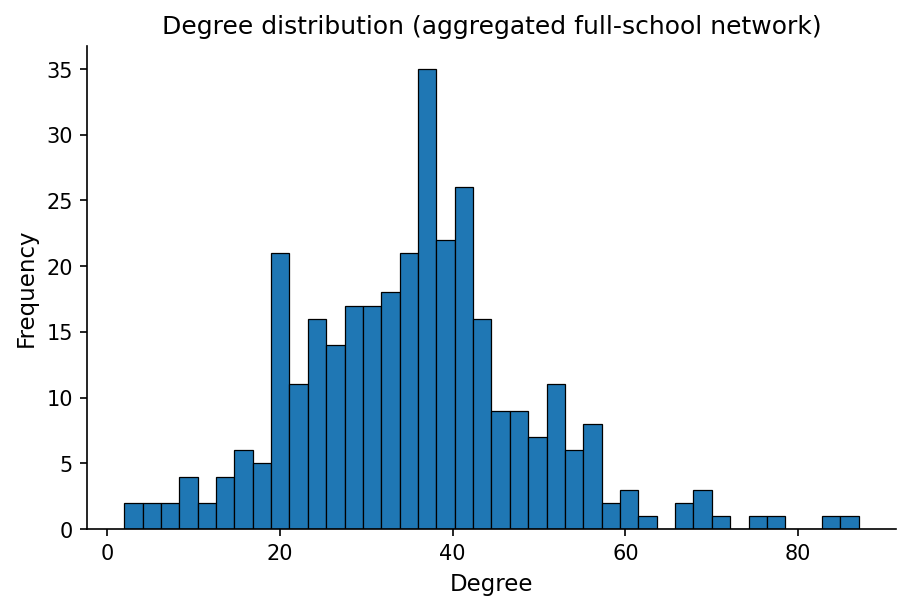

In [ ]:
# ============================================================
# 1) Degree histogram
# ============================================================
degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(degrees, bins=40, edgecolor="black", linewidth=0.6)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree distribution (aggregated full-school network)")
save_fig("degree_histogram")
plt.show()

Saved: figures/strength_histogram_duration.png
Saved: figures/strength_histogram_duration.pdf


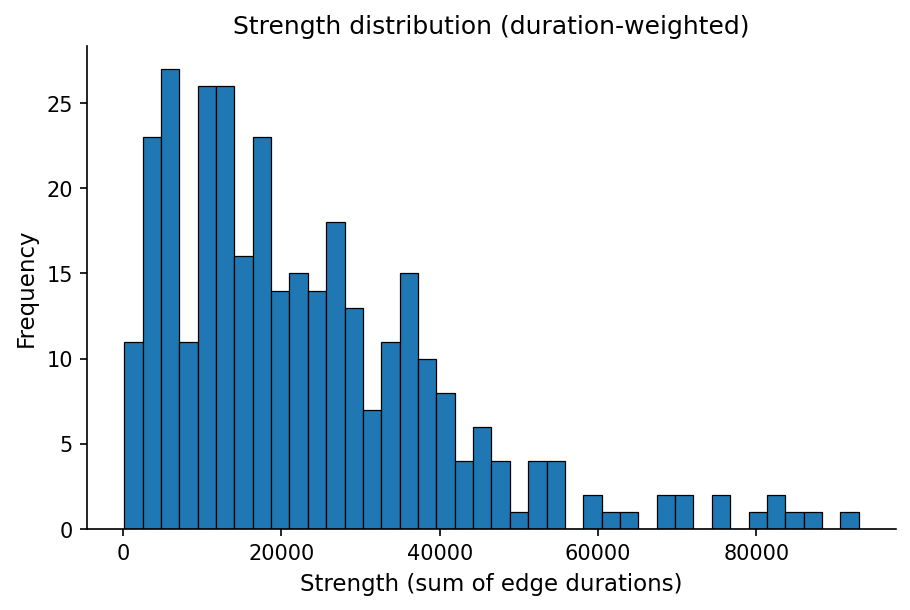

In [ ]:
# ============================================================
# 2) Strength histogram (duration_s)
# ============================================================
strengths = np.array([G.degree(n, weight="duration_s") for n in G.nodes()], dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(strengths, bins=40, edgecolor="black", linewidth=0.6)
plt.xlabel("Strength (sum of edge durations)")
plt.ylabel("Frequency")
plt.title("Strength distribution (duration-weighted)")
save_fig("strength_histogram_duration")
plt.show()

Saved: figures/curvature_histogram_duration_norm.png
Saved: figures/curvature_histogram_duration_norm.pdf


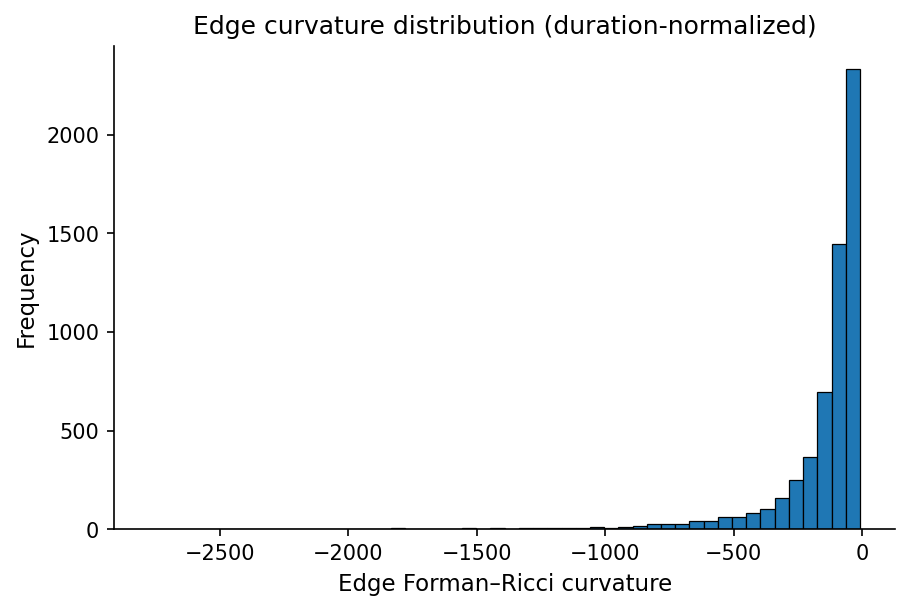

In [ ]:
# ============================================================
# 3) Curvature histogram (duration-normalized curvature)
# Use:
#  - edges_curv_dur["curvature"] if available
#  - else fallback to curv_dur dict
# ============================================================
if "curvature" in edges_curv_dur.columns:
    curv_vals = edges_curv_dur["curvature"].to_numpy(dtype=float)
else:
    curv_vals = np.array(list(curv_dur.values()), dtype=float)

plt.figure(figsize=(6.2, 4.2))
plt.hist(curv_vals, bins=50, edgecolor="black", linewidth=0.6)
plt.xlabel("Edge Forman–Ricci curvature")
plt.ylabel("Frequency")
plt.title("Edge curvature distribution (duration-normalized)")
save_fig("curvature_histogram_duration_norm")
plt.show()

Saved: figures/curvature_vs_betweenness_scatter.png
Saved: figures/curvature_vs_betweenness_scatter.pdf


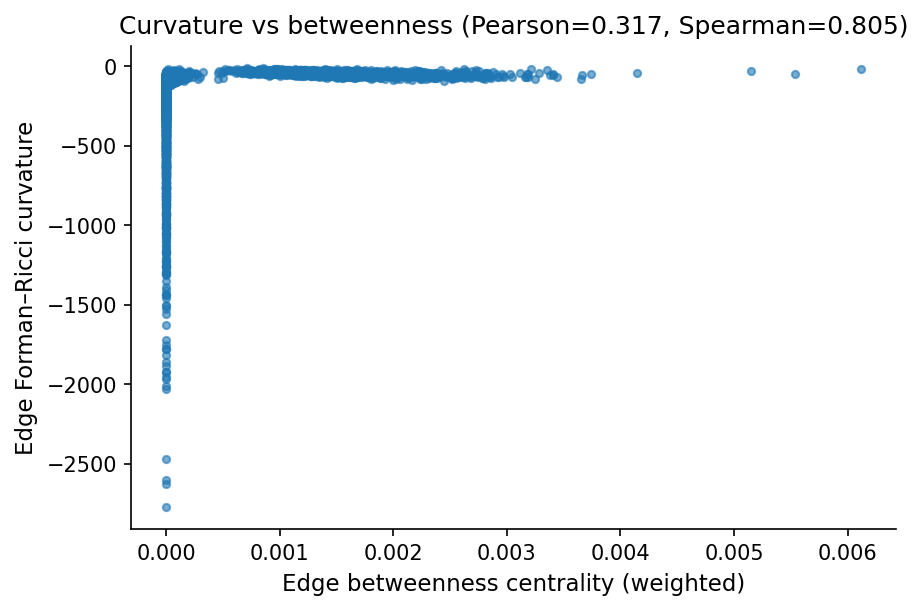

In [ ]:
# ============================================================
# 4) Curvature vs edge betweenness scatter (+ correlations)
# Requires edges_curv_dur has 'edge_betweenness'
# ============================================================
if "edge_betweenness" not in edges_curv_dur.columns:
    raise ValueError("edges_curv_dur must contain 'edge_betweenness'. Compute it before plotting.")

x = edges_curv_dur["edge_betweenness"].to_numpy(dtype=float)
y = edges_curv_dur["curvature"].to_numpy(dtype=float)

def safe_corr(a, b) -> float:
    if len(a) < 3:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])

pearson = safe_corr(x, y)

# Spearman without scipy: rank-transform then Pearson
rx = pd.Series(x).rank(method="average").to_numpy()
ry = pd.Series(y).rank(method="average").to_numpy()
spearman = safe_corr(rx, ry)

plt.figure(figsize=(6.2, 4.2))
plt.scatter(x, y, s=12, alpha=0.6)
plt.xlabel("Edge betweenness centrality (weighted)")
plt.ylabel("Edge Forman–Ricci curvature")
plt.title(f"Curvature vs betweenness (Pearson={pearson:.3f}, Spearman={spearman:.3f})")
save_fig("curvature_vs_betweenness_scatter")
plt.show()

Added edge attribute: 'w_dur_sat_norm' with c = 0.001046361255170799
Saved: figures/curvature_sir_curves_duration_norm_linear_band.png
Saved: figures/curvature_sir_curves_duration_norm_linear_band.pdf


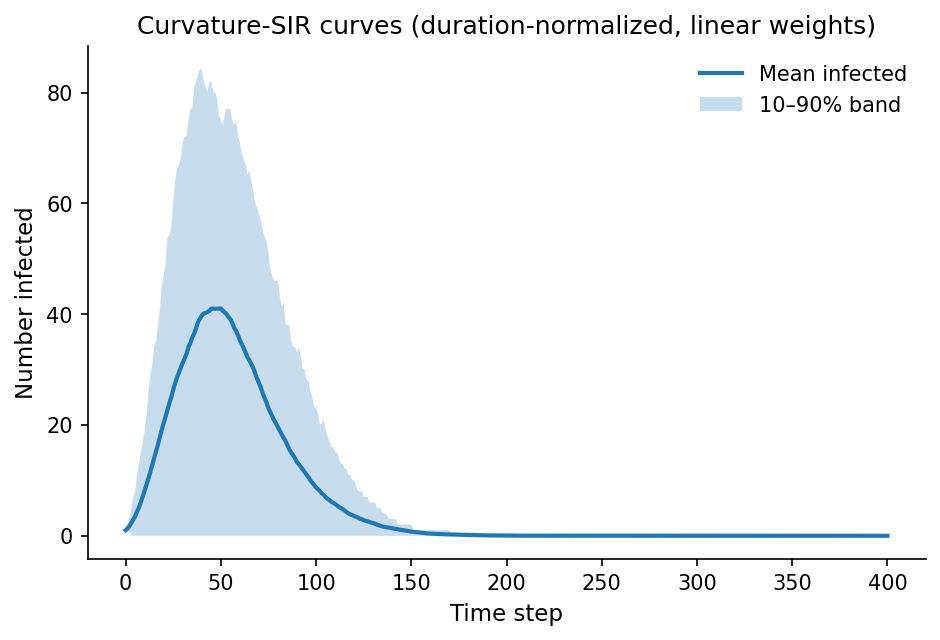

Saved: figures/curvature_sir_curves_duration_norm_saturating_band.png
Saved: figures/curvature_sir_curves_duration_norm_saturating_band.pdf


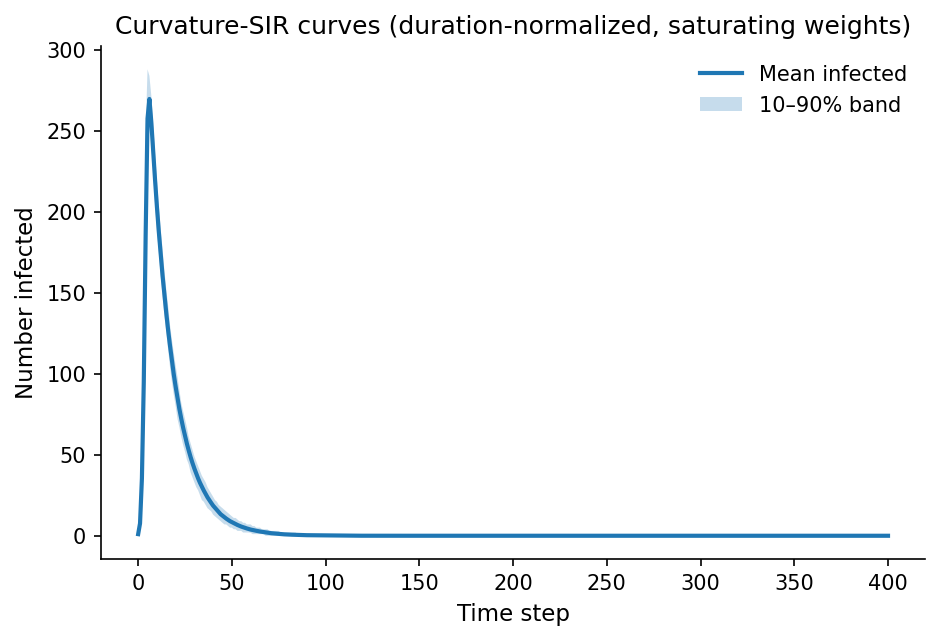

Saved: figures/curvature_sir_mean_overlay_linear_vs_saturating.png
Saved: figures/curvature_sir_mean_overlay_linear_vs_saturating.pdf


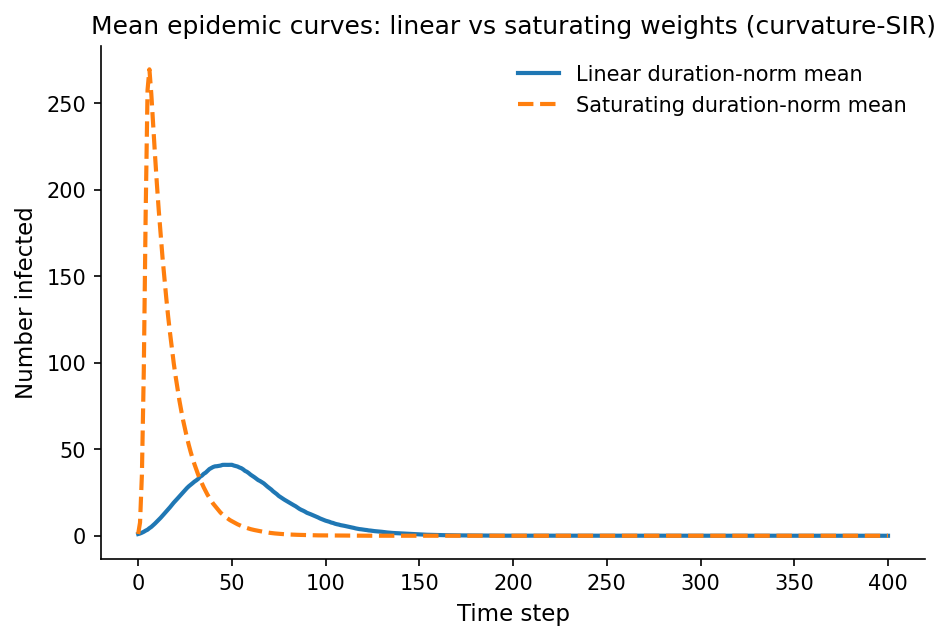

In [ ]:
# ============================================================
# 5) Epidemic curves with confidence bands (curvature-SIR) — TWEAKED
# Goal: make the "sensitivity" comparison meaningful.
#
# Reason: our previous duration-vs-count curves overlap:
#   duration_ij = 20 * count_ij  and after max-normalization => identical weights.
#
# This tweak compares:
#   (A) duration-norm linear weights  : w_dur_norm  (as before)
#   (B) duration-norm SATURATING map  : w_sat = (1 - exp(-c * duration_s)) normalized
#
# This keeps the SAME simulator and curvature law:
#   beta_ij = beta0 * exp(F(e_ij))
#   p_ij = 1 - exp(-beta_ij * w_ij)
# ============================================================

# -----------------------------
# Build a saturating-weight attribute (publishable sensitivity)
# -----------------------------
def add_saturating_weight(
    G: nx.Graph,
    source_attr: str = "duration_s",
    out_attr: str = "w_dur_sat_norm",
    c: float = 1.0,
    eps: float = 1e-12
) -> None:
    """
    Create a saturating transform of edge weight:
      w_sat = 1 - exp(-c * w_raw)
    then normalize by max so it's in (0,1].

    Parameters
    ----------
    source_attr : str
        Raw edge attribute (e.g., 'duration_s' or 'count')
    out_attr : str
        New edge attribute name
    c : float
        Saturation constant. Larger c => faster saturation.
    """
    vals = []
    for u, v, d in G.edges(data=True):
        w_raw = float(d.get(source_attr, 0.0))
        w_raw = max(w_raw, 0.0)
        w_sat = 1.0 - math.exp(-c * w_raw)
        d[out_attr] = w_sat
        vals.append(w_sat)

    mx = max(vals) if len(vals) else 1.0
    mx = max(mx, eps)
    for u, v, d in G.edges(data=True):
        d[out_attr] = float(d[out_attr]) / mx


# -----------------------------
# Optional helper: choose c automatically (robust)
# c is picked so that the 95th percentile maps to a target saturation level.
# Example: want w_sat(q95) ≈ 0.95  =>  1-exp(-c*q95)=0.95 => c = -ln(0.05)/q95
# -----------------------------
def choose_c_for_target_saturation(
    G: nx.Graph,
    source_attr: str = "duration_s",
    target_level: float = 0.95,
    quantile: float = 0.95,
    eps: float = 1e-12
) -> float:
    w = np.array([float(d.get(source_attr, 0.0)) for _, _, d in G.edges(data=True)], dtype=float)
    w = np.clip(w, 0.0, None)
    if len(w) == 0:
        return 1.0
    q = float(np.quantile(w, quantile))
    q = max(q, eps)
    target_level = min(max(target_level, eps), 1 - eps)
    c = -math.log(1 - target_level) / q
    return float(c)


# Pick c based on your data (recommended)
c_auto = choose_c_for_target_saturation(G, source_attr="duration_s", target_level=0.95, quantile=0.95)
add_saturating_weight(G, source_attr="duration_s", out_attr="w_dur_sat_norm", c=c_auto)

print("Added edge attribute: 'w_dur_sat_norm' with c =", c_auto)


# ============================================================
# Epidemic curves with confidence bands (curvature-SIR)
# Uses simulate_curvature_sir_discrete() defined earlier.
# ============================================================
def curvature_sir_ensemble_curves(
    G: nx.Graph,
    beta0: float,
    gamma: float,
    weight_attr: str,
    curvature_attr: str = "formanCurvature",
    n_runs: int = 300,
    seed0: int = 2024,
    max_steps: int = 400
) -> np.ndarray:
    """
    Returns array of shape (n_runs, T) where T=max_steps+1.
    Curves are padded with zeros after extinction.
    """
    curves = []
    for r in range(n_runs):
        res = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + r,
            max_steps=max_steps
        )
        c = np.array(res.curve_I, dtype=float)
        if len(c) < max_steps + 1:
            c = np.pad(c, (0, max_steps + 1 - len(c)), constant_values=0.0)
        else:
            c = c[:max_steps + 1]
        curves.append(c)
    return np.vstack(curves)


def plot_epidemic_band(curves: np.ndarray, title: str, fname: str):
    t = np.arange(curves.shape[1])
    mean = curves.mean(axis=0)
    lo = np.percentile(curves, 10, axis=0)
    hi = np.percentile(curves, 90, axis=0)

    plt.figure(figsize=(6.4, 4.4))
    plt.plot(t, mean, linewidth=2.0, label="Mean infected")
    plt.fill_between(t, lo, hi, alpha=0.25, label="10–90% band")
    plt.xlabel("Time step")
    plt.ylabel("Number infected")
    plt.title(title)
    plt.legend(frameon=False)
    save_fig(fname)
    plt.show()


# ---- Use SAME parameters as your curvature-SIR runs
BETA0 = 1.2
GAMMA = 0.08

# A) Duration-normalized (linear) curves
curves_dur = curvature_sir_ensemble_curves(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_norm",
    curvature_attr="formanCurvature",
    n_runs=300, seed0=2024, max_steps=400
)
plot_epidemic_band(
    curves_dur,
    title="Curvature-SIR curves (duration-normalized, linear weights)",
    fname="curvature_sir_curves_duration_norm_linear_band"
)

# B) Duration SATURATING curves (meaningful sensitivity)
curves_sat = curvature_sir_ensemble_curves(
    G, beta0=BETA0, gamma=GAMMA,
    weight_attr="w_dur_sat_norm",
    curvature_attr="formanCurvature",
    n_runs=300, seed0=2024, max_steps=400
)
plot_epidemic_band(
    curves_sat,
    title="Curvature-SIR curves (duration-normalized, saturating weights)",
    fname="curvature_sir_curves_duration_norm_saturating_band"
)

# Optional: overlay both MEANS (paper-friendly comparison)
t = np.arange(curves_dur.shape[1])
mean_dur = curves_dur.mean(axis=0)
mean_sat = curves_sat.mean(axis=0)

plt.figure(figsize=(6.4, 4.4))
plt.plot(t, mean_dur, linewidth=2.0, label="Linear duration-norm mean")
plt.plot(t, mean_sat, linewidth=2.0, linestyle="--", label="Saturating duration-norm mean")
plt.xlabel("Time step")
plt.ylabel("Number infected")
plt.title("Mean epidemic curves: linear vs saturating weights (curvature-SIR)")
plt.legend(frameon=False)
save_fig("curvature_sir_mean_overlay_linear_vs_saturating")
plt.show()

In [ ]:
print("\nAll updated figures saved to:", FIG_DIR)

In [ ]:
# ============================================================
# EXPERIMENT 6
# EMPIRICAL HIGH-SCHOOL NETWORK VALIDATION
# ============================================================


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

E6_SEED0 = 20260907

# ------------------------------------------------------------
# Epidemic parameters
# ------------------------------------------------------------

E6_BETA0 = 1.2
E6_GAMMA = 0.08

# ------------------------------------------------------------
# Curvature-strength parameter
# ------------------------------------------------------------

E6_ALPHA_MAIN = 1.0

E6_ALPHA_GRID = np.array([
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00
])

# ------------------------------------------------------------
# Simulation settings
# ------------------------------------------------------------

E6_N_RUNS = 200
E6_MAX_STEPS = 2000

# ------------------------------------------------------------
# Primary empirical weight
# ------------------------------------------------------------

E6_WEIGHT_ATTR = "w_dur_norm"

# ------------------------------------------------------------
# Numerical safeguard
# ------------------------------------------------------------

E6_EPSILON = 1e-6

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

E6_OUTPUT_DIR = "experiment6_results"

os.makedirs(
    E6_OUTPUT_DIR,
    exist_ok=True
)

print("Experiment 6 configuration loaded.")
print("beta0 =", E6_BETA0)
print("gamma =", E6_GAMMA)
print("alpha =", E6_ALPHA_MAIN)
print("runs  =", E6_N_RUNS)
print("weight =", E6_WEIGHT_ATTR)

In [ ]:
# ============================================================
# STEP 6.1 — VERIFY EMPIRICAL NETWORK
# ============================================================

print("Number of nodes :", G.number_of_nodes())
print("Number of edges :", G.number_of_edges())

if G.number_of_nodes() == 0:
    raise ValueError("Empirical network G contains no nodes.")

if G.number_of_edges() == 0:
    raise ValueError("Empirical network G contains no edges.")

# Check that the primary transmission weight exists
missing_weight = sum(
    1
    for _, _, d in G.edges(data=True)
    if E6_WEIGHT_ATTR not in d
)

print(
    f"Edges missing '{E6_WEIGHT_ATTR}':",
    missing_weight
)

if missing_weight > 0:
    raise ValueError(
        f"Some edges are missing the required weight attribute "
        f"'{E6_WEIGHT_ATTR}'."
    )

In [ ]:
# ============================================================
# STEP 6.2 — TRANSFER WEIGHTED FRC TO EMPIRICAL NETWORK
# ============================================================

if "G_frc_dur" not in globals():
    raise ValueError(
        "G_frc_dur is not available. "
        "Run the weighted Forman-Ricci curvature calculation first."
    )

for u, v, d in G.edges(data=True):

    if G_frc_dur.has_edge(u, v):

        d["formanCurvature"] = float(
            G_frc_dur[u][v].get(
                "formanCurvature",
                0.0
            )
        )

    elif G_frc_dur.has_edge(v, u):

        d["formanCurvature"] = float(
            G_frc_dur[v][u].get(
                "formanCurvature",
                0.0
            )
        )

    else:

        raise ValueError(
            f"Could not find FRC for edge ({u}, {v})."
        )

print(
    "Weighted Forman-Ricci curvature "
    "successfully transferred to G."
)

In [ ]:
# ============================================================
# STEP 6.3 — VERIFY CURVATURE TRANSFER
# ============================================================

e6_curvature_values = np.array(
    [
        float(d["formanCurvature"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

print("Curvature summary")
print("-----------------")
print("Number of edges :", len(e6_curvature_values))
print("Minimum         :", e6_curvature_values.min())
print("Maximum         :", e6_curvature_values.max())
print("Mean            :", e6_curvature_values.mean())
print("Median          :", np.median(e6_curvature_values))
print("SD              :", e6_curvature_values.std(ddof=1))
print(
    "Non-zero edges  :",
    np.sum(e6_curvature_values != 0)
)

if np.allclose(
    e6_curvature_values,
    0.0
):
    raise ValueError(
        "All transferred curvature values are zero. "
        "FRC transfer failed."
    )

In [ ]:
# ============================================================
# STEP 6.4 — STANDARDIZE EMPIRICAL CURVATURE
# ============================================================

e6_F_mean = np.mean(
    e6_curvature_values
)

e6_F_sd = np.std(
    e6_curvature_values,
    ddof=1
)

if e6_F_sd <= 0:
    raise ValueError(
        "Empirical curvature has zero variance."
    )

for u, v, d in G.edges(data=True):

    F = float(
        d["formanCurvature"]
    )

    d["curvature_std"] = (
        F - e6_F_mean
    ) / e6_F_sd

print(
    "Standardized curvature attached "
    "as 'curvature_std'."
)

print(
    "Mean standardized curvature:",
    np.mean([
        d["curvature_std"]
        for _, _, d in G.edges(data=True)
    ])
)

print(
    "SD standardized curvature:",
    np.std([
        d["curvature_std"]
        for _, _, d in G.edges(data=True)
    ], ddof=1)
)

In [ ]:
# ============================================================
# STEP 6.5 — STANDARD WEIGHTED NETWORK-SIR BASELINE
# ============================================================

for u, v, d in G.edges(data=True):

    d["curvature_zero"] = 0.0

e6_network_sir = run_curvature_sir_ensemble(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_zero",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

print("\n--- Standard weighted Network-SIR ---")
print(e6_network_sir)

In [ ]:
# ============================================================
# STEP 6.6 — CURVATURE-SIR
# ============================================================

e6_curvature_sir = run_curvature_sir_ensemble(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_std",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

print("\n--- Curvature-SIR ---")
print(e6_curvature_sir)


--- Curvature-SIR ---
{'beta0': 1.2, 'gamma': 0.08, 'weight_attr': 'w_dur_norm', 'curvature_attr': 'curvature_std', 'peak_I_mean': 8.7, 'peak_t_mean': 29.13, 'final_size_mean': 40.315, 'peak_I_p90': 26.0, 'final_size_p90': 146.1}


In [ ]:
# ============================================================
# STEP 6.7 — EMPIRICAL CURVATURE EFFECT
# ============================================================

e6_baseline_peak = e6_network_sir["peak_I_mean"]
e6_curvature_peak = e6_curvature_sir["peak_I_mean"]

e6_baseline_time = e6_network_sir["peak_t_mean"]
e6_curvature_time = e6_curvature_sir["peak_t_mean"]

e6_baseline_final = e6_network_sir["final_size_mean"]
e6_curvature_final = e6_curvature_sir["final_size_mean"]

e6_effects = pd.DataFrame([{

    "Network":
        "High-School",

    "Baseline_Peak":
        e6_baseline_peak,

    "Curvature_Peak":
        e6_curvature_peak,

    "Peak_Change_Pct":
        (
            (e6_curvature_peak - e6_baseline_peak)
            / e6_baseline_peak
            * 100
        ),

    "Baseline_Peak_Time":
        e6_baseline_time,

    "Curvature_Peak_Time":
        e6_curvature_time,

    "Peak_Time_Change_Pct":
        (
            (e6_curvature_time - e6_baseline_time)
            / e6_baseline_time
            * 100
        ),

    "Baseline_Final_Size":
        e6_baseline_final,

    "Curvature_Final_Size":
        e6_curvature_final,

    "Final_Size_Change_Pct":
        (
            (e6_curvature_final - e6_baseline_final)
            / e6_baseline_final
            * 100
        )

}])

e6_effects

In [ ]:
# ============================================================
# STEP 6.8 — UNCERTAINTY SUMMARY
# ============================================================

e6_uncertainty = pd.DataFrame([

    {
        "Model":
            "Standard weighted Network-SIR",

        "Peak_I_Mean":
            e6_network_sir["peak_I_mean"],

        "Peak_I_P90":
            e6_network_sir["peak_I_p90"],

        "Final_Size_Mean":
            e6_network_sir["final_size_mean"],

        "Final_Size_P90":
            e6_network_sir["final_size_p90"]
    },

    {
        "Model":
            "Curvature-SIR",

        "Peak_I_Mean":
            e6_curvature_sir["peak_I_mean"],

        "Peak_I_P90":
            e6_curvature_sir["peak_I_p90"],

        "Final_Size_Mean":
            e6_curvature_sir["final_size_mean"],

        "Final_Size_P90":
            e6_curvature_sir["final_size_p90"]
    }

])

e6_uncertainty

In [ ]:
# ============================================================
# STEP 6.9 — CURVATURE-TO-TRANSMISSION MAPPINGS
# ============================================================

def attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=1.0
):

    F = np.array(
        [
            float(
                d.get(source_attr, 0.0)
            )
            for _, _, d in G.edges(data=True)
        ],
        dtype=float
    )

    # --------------------------------------------------------
    # Uniform mapping
    # --------------------------------------------------------

    g_uniform = np.ones_like(F)

    # --------------------------------------------------------
    # Linear mapping
    # --------------------------------------------------------

    g_linear = np.maximum(
        E6_EPSILON,
        1.0 + alpha * F
    )

    # --------------------------------------------------------
    # Exponential mapping
    # --------------------------------------------------------

    g_exponential = np.exp(
        alpha * F
    )

    # --------------------------------------------------------
    # Saturating mapping
    # --------------------------------------------------------

    g_saturating = (
        1.0 +
        np.tanh(alpha * F)
    )

    # --------------------------------------------------------
    # Mean-normalize each mapping
    # --------------------------------------------------------

    g_uniform /= np.mean(g_uniform)

    g_linear /= np.mean(g_linear)

    g_exponential /= np.mean(
        g_exponential
    )

    g_saturating /= np.mean(
        g_saturating
    )

    # --------------------------------------------------------
    # Store mapping values directly for diagnostics
    # --------------------------------------------------------

    for idx, (u, v, d) in enumerate(
        G.edges(data=True)
    ):

        d["mapping_uniform_value"] = (
            float(g_uniform[idx])
        )

        d["mapping_linear_value"] = (
            float(g_linear[idx])
        )

        d["mapping_exponential_value"] = (
            float(g_exponential[idx])
        )

        d["mapping_saturating_value"] = (
            float(g_saturating[idx])
        )

        # ----------------------------------------------------
        # Existing simulator applies exp(kappa)
        # Therefore store log(mapping)
        # ----------------------------------------------------

        d["mapping_uniform"] = 0.0

        d["mapping_linear"] = math.log(
            max(
                g_linear[idx],
                E6_EPSILON
            )
        )

        d["mapping_exponential"] = math.log(
            max(
                g_exponential[idx],
                E6_EPSILON
            )
        )

        d["mapping_saturating"] = math.log(
            max(
                g_saturating[idx],
                E6_EPSILON
            )
        )

    return G

In [ ]:
# ============================================================
# STEP 6.10 — ATTACH AND VERIFY MAPPINGS
# ============================================================

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=E6_ALPHA_MAIN
)

mapping_columns = [
    "mapping_uniform_value",
    "mapping_linear_value",
    "mapping_exponential_value",
    "mapping_saturating_value"
]

mapping_summary = []

for col in mapping_columns:

    values = np.array([
        float(d[col])
        for _, _, d in G.edges(data=True)
    ])

    mapping_summary.append({

        "Mapping":
            col,

        "Mean":
            values.mean(),

        "SD":
            values.std(ddof=1),

        "Min":
            values.min(),

        "Max":
            values.max(),

        "Unique_Values":
            len(np.unique(values))

    })

e6_mapping_check = pd.DataFrame(
    mapping_summary
)

e6_mapping_check

In [ ]:
# ============================================================
# STEP 6.10A — VERIFY NORMALISED EXPONENTIAL MAPPING
# ============================================================

# The exponential curvature modifier used in the epidemic
# simulation must have mean equal to one at the main
# curvature strength.

exponential_mapping_values = np.array(
    [
        float(d["mapping_exponential_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

exponential_mapping_mean = (
    exponential_mapping_values.mean()
)

print(
    "NORMALISED EXPONENTIAL MAPPING CHECK"
)
print("=" * 60)

print(
    f"Alpha                 : "
    f"{E6_ALPHA_MAIN:.2f}"
)

print(
    f"Mean modifier         : "
    f"{exponential_mapping_mean:.12f}"
)

print(
    f"Minimum modifier      : "
    f"{exponential_mapping_values.min():.6f}"
)

print(
    f"Maximum modifier      : "
    f"{exponential_mapping_values.max():.6f}"
)

if not np.isclose(
    exponential_mapping_mean,
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Mean-normalised exponential mapping "
        "does not have mean equal to one."
    )

print(
    "✓ Mean-normalised exponential mapping "
    "verified."
)

NORMALISED EXPONENTIAL MAPPING CHECK
Alpha                 : 1.00
Mean modifier         : 1.000000000000
Minimum modifier      : 0.000004
Maximum modifier      : 1.585846
✓ Mean-normalised exponential mapping verified.


In [ ]:
# ============================================================
# FUNCTION — EXTENDED SIR ENSEMBLE
# ============================================================

def run_curvature_sir_ensemble_extended(
    G,
    beta0,
    gamma,
    weight_attr,
    curvature_attr="formanCurvature",
    n_runs=200,
    seed0=123,
    max_steps=2000
):

    peak_I = []
    peak_t = []
    final_size = []
    duration = []
    hit_max_steps = []
    infected_curves = []

    for run in range(n_runs):

        result = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + run,
            max_steps=max_steps
        )

        # ----------------------------------------------------
        # Epidemiological outcomes
        # ----------------------------------------------------

        peak_I.append(
            float(result.peak_infected)
        )

        peak_t.append(
            float(result.peak_time)
        )

        final_size.append(
            float(result.final_size)
        )

        # ----------------------------------------------------
        # Epidemic curve
        # ----------------------------------------------------

        curve_I = np.asarray(
            result.curve_I,
            dtype=float
        )

        infected_curves.append(
            curve_I
        )

        # ----------------------------------------------------
        # Epidemic duration
        # ----------------------------------------------------

        run_duration = len(curve_I) - 1

        duration.append(
            run_duration
        )

        # ----------------------------------------------------
        # Maximum-step truncation diagnostic
        # ----------------------------------------------------

        hit_max_steps.append(
            run_duration >= max_steps
            and curve_I[-1] > 0
        )

    # --------------------------------------------------------
    # Pad epidemic curves
    # --------------------------------------------------------

    max_len = max(
        len(curve)
        for curve in infected_curves
    )

    padded_curves = np.full(
        (n_runs, max_len),
        np.nan,
        dtype=float
    )

    for i, curve in enumerate(
        infected_curves
    ):

        padded_curves[
            i,
            :len(curve)
        ] = curve

    # --------------------------------------------------------
    # Run-level metrics
    # --------------------------------------------------------

    metrics = pd.DataFrame({

        "Peak_Infected":
            peak_I,

        "Peak_Time":
            peak_t,

        "Final_Size":
            final_size,

        "Duration":
            duration,

        "Hit_Max_Steps":
            hit_max_steps
    })

    return {
        "metrics":
            metrics,

        "infected_curves":
            padded_curves,

        "beta0":
            beta0,

        "gamma":
            gamma,

        "weight_attr":
            weight_attr,

        "curvature_attr":
            curvature_attr
    }

In [ ]:
# ============================================================
# VERIFY EXTENDED ENSEMBLE FUNCTION
# ============================================================

print(
    "run_curvature_sir_ensemble_extended"
    in globals()
)

print(
    run_curvature_sir_ensemble_extended
)

True
<function run_curvature_sir_ensemble_extended at 0x7bff0b3004a0>


In [ ]:
# ============================================================
# FUNCTION — STATISTICAL SUMMARY
# ============================================================

def summarize_metric(values):

    values = np.asarray(
        values,
        dtype=float
    )

    # Remove missing/infinite values
    values = values[
        np.isfinite(values)
    ]

    n = len(values)

    if n == 0:
        raise ValueError(
            "No valid observations were provided."
        )

    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------

    mean = np.mean(values)

    # --------------------------------------------------------
    # Standard deviation
    # --------------------------------------------------------

    sd = (
        np.std(
            values,
            ddof=1
        )
        if n > 1
        else 0.0
    )

    # --------------------------------------------------------
    # Median and IQR
    # --------------------------------------------------------

    median = np.median(
        values
    )

    q25, q75 = np.percentile(
        values,
        [25, 75]
    )

    # --------------------------------------------------------
    # 95% confidence interval for the mean
    #
    # Use the t distribution rather than the normal
    # approximation because this is the appropriate
    # finite-sample CI calculation.
    # --------------------------------------------------------

    if n > 1:

        t_critical = scipy_stats.t.ppf(
            0.975,
            df=n - 1
        )

        se = (
            sd /
            np.sqrt(n)
        )

        ci_lower = (
            mean -
            t_critical * se
        )

        ci_upper = (
            mean +
            t_critical * se
        )

    else:

        ci_lower = mean
        ci_upper = mean

    # --------------------------------------------------------
    # Return summary
    # --------------------------------------------------------

    return {

        "N":
            n,

        "Mean":
            mean,

        "SD":
            sd,

        "CI95_Lower":
            ci_lower,

        "CI95_Upper":
            ci_upper,

        "Median":
            median,

        "IQR_Lower":
            q25,

        "IQR_Upper":
            q75
    }

In [ ]:
print(
    "summarize_metric" in globals()
)

print(
    summarize_metric
)

True
<function summarize_metric at 0x7bff0b301c60>


In [ ]:
test_values = np.array([
    1, 2, 3, 4, 5
])

test_summary = summarize_metric(
    test_values
)

test_summary

{'N': 5,
 'Mean': np.float64(3.0),
 'SD': np.float64(1.5811388300841898),
 'CI95_Lower': np.float64(1.036756838522439),
 'CI95_Upper': np.float64(4.9632431614775605),
 'Median': np.float64(3.0),
 'IQR_Lower': np.float64(2.0),
 'IQR_Upper': np.float64(4.0)}

In [ ]:
# ============================================================
# STEP 6.11 — EXPERIMENT 6B
# MAPPING ROBUSTNESS
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# Rebuild all mapping attributes explicitly at the main
# curvature strength before running the comparison.
#
# This prevents STEP 6.13 (alpha sensitivity) from leaving
# G with mappings corresponding to the final alpha value.
# ------------------------------------------------------------

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)


E6_MAPPINGS = {
    "Uniform":
        "mapping_uniform",

    "Linear":
        "mapping_linear",

    "Exponential":
        "mapping_exponential",

    "Saturating":
        "mapping_saturating"
}


e6_mapping_results = []


for mapping_name, curvature_attr in E6_MAPPINGS.items():

    print(
        f"\nRunning mapping: {mapping_name}"
    )

    output = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr=curvature_attr,
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    metrics = output["metrics"]

    # --------------------------------------------------------
    # Check that no runs were truncated
    # --------------------------------------------------------

    n_truncated = int(
        metrics["Hit_Max_Steps"].sum()
    )

    if n_truncated > 0:
        raise RuntimeError(
            f"{mapping_name} mapping has "
            f"{n_truncated} truncated runs."
        )

    # --------------------------------------------------------
    # Summarize the four epidemiological outcomes
    # --------------------------------------------------------

    peak_summary = summarize_metric(
        metrics["Peak_Infected"]
    )

    peak_time_summary = summarize_metric(
        metrics["Peak_Time"]
    )

    final_size_summary = summarize_metric(
        metrics["Final_Size"]
    )

    duration_summary = summarize_metric(
        metrics["Duration"]
    )

    e6_mapping_results.append({

        "Network":
            "High-School",

        "Mapping":
            mapping_name,

        "Alpha":
            float(E6_ALPHA_MAIN),

        # Peak infected
        "Peak_Infected_Mean":
            peak_summary["Mean"],

        "Peak_Infected_SD":
            peak_summary["SD"],

        "Peak_Infected_CI95_Lower":
            peak_summary["CI95_Lower"],

        "Peak_Infected_CI95_Upper":
            peak_summary["CI95_Upper"],

        # Peak time
        "Peak_Time_Mean":
            peak_time_summary["Mean"],

        "Peak_Time_SD":
            peak_time_summary["SD"],

        "Peak_Time_CI95_Lower":
            peak_time_summary["CI95_Lower"],

        "Peak_Time_CI95_Upper":
            peak_time_summary["CI95_Upper"],

        # Final size
        "Final_Size_Mean":
            final_size_summary["Mean"],

        "Final_Size_SD":
            final_size_summary["SD"],

        "Final_Size_CI95_Lower":
            final_size_summary["CI95_Lower"],

        "Final_Size_CI95_Upper":
            final_size_summary["CI95_Upper"],

        # Duration
        "Duration_Mean":
            duration_summary["Mean"],

        "Duration_SD":
            duration_summary["SD"],

        "Duration_CI95_Lower":
            duration_summary["CI95_Lower"],

        "Duration_CI95_Upper":
            duration_summary["CI95_Upper"],

        # Distributional summaries
        "Peak_Infected_Median":
            peak_summary["Median"],

        "Peak_Infected_IQR_Lower":
            peak_summary["IQR_Lower"],

        "Peak_Infected_IQR_Upper":
            peak_summary["IQR_Upper"],

        "Final_Size_Median":
            final_size_summary["Median"],

        "Final_Size_IQR_Lower":
            final_size_summary["IQR_Lower"],

        "Final_Size_IQR_Upper":
            final_size_summary["IQR_Upper"],

        "Duration_Median":
            duration_summary["Median"],

        "Duration_IQR_Lower":
            duration_summary["IQR_Lower"],

        "Duration_IQR_Upper":
            duration_summary["IQR_Upper"],

        "N":
            peak_summary["N"]
    })


e6_mapping_df = pd.DataFrame(
    e6_mapping_results
)

e6_mapping_df


Running mapping: Uniform

Running mapping: Linear

Running mapping: Exponential

Running mapping: Saturating


,Network,Mapping,Alpha,Peak_Infected_Mean,Peak_Infected_SD,Peak_Infected_CI95_Lower,Peak_Infected_CI95_Upper,Peak_Time_Mean,Peak_Time_SD,Peak_Time_CI95_Lower,...,Peak_Infected_Median,Peak_Infected_IQR_Lower,Peak_Infected_IQR_Upper,Final_Size_Median,Final_Size_IQR_Lower,Final_Size_IQR_Upper,Duration_Median,Duration_IQR_Lower,Duration_IQR_Upper,N
0,High-School,Uniform,1.0,59.680,37.270404,54.483075,64.876925,36.200,24.990450,32.715372,...,73.0,11.75,87.0,274.0,26.25,282.00,119.5,61.5,144.00,200
1,High-School,Linear,1.0,2.975,2.864507,2.575578,3.374422,15.035,28.047407,11.124115,...,2.0,1.00,4.0,2.0,1.00,7.00,17.0,6.0,45.25,200
2,High-School,Exponential,1.0,5.065,5.975728,4.231754,5.898246,20.745,29.451774,16.638292,...,2.0,1.00,7.0,3.0,1.00,22.25,18.0,6.0,87.25,200
3,High-School,Saturating,1.0,3.695,4.186839,3.111194,4.278806,17.330,29.113900,13.270405,...,2.0,1.00,5.0,2.0,1.00,9.25,18.0,6.0,55.00,200


In [ ]:
# ============================================================
# STEP 6.11A — VERIFY MAPPING EXPERIMENT STATE
# ============================================================

print("MAPPING EXPERIMENT STATE CHECK")
print("=" * 50)

print(
    f"Configured main alpha: {E6_ALPHA_MAIN}"
)

print(
    f"Reported mapping alpha: "
    f"{e6_mapping_df['Alpha'].unique()}"
)

if not np.allclose(
    e6_mapping_df["Alpha"].to_numpy(dtype=float),
    float(E6_ALPHA_MAIN)
):
    raise RuntimeError(
        "Mapping results do not correspond to E6_ALPHA_MAIN."
    )

print(
    "✓ All mapping results are labelled with E6_ALPHA_MAIN."
)

In [ ]:
mapping_state_check = {}

for mapping_name, curvature_attr in E6_MAPPINGS.items():

    values = np.array([
        float(d.get(curvature_attr, np.nan))
        for _, _, d in G.edges(data=True)
    ])

    mapping_state_check[mapping_name] = {
        "Mean_log_mapping": np.mean(values),
        "SD_log_mapping": np.std(values, ddof=1),
        "Min_log_mapping": np.min(values),
        "Max_log_mapping": np.max(values)
    }

pd.DataFrame(mapping_state_check).T

In [ ]:
# ============================================================
# STEP 6.12 — RELATIVE MAPPING EFFECTS
# ============================================================

e6_uniform = (
    e6_mapping_df[
        e6_mapping_df["Mapping"] == "Uniform"
    ]
    .iloc[0]
)

e6_mapping_effects = e6_mapping_df.copy()

e6_mapping_effects[
    "Peak_Change_Pct"
] = (
    (
        e6_mapping_effects["Peak_Infected_Mean"]
        - e6_uniform["Peak_Infected_Mean"]
    )
    /
    e6_uniform["Peak_Infected_Mean"]
    * 100
)

e6_mapping_effects[
    "Peak_Time_Change_Pct"
] = (
    (
        e6_mapping_effects["Peak_Time_Mean"]
        - e6_uniform["Peak_Time_Mean"]
    )
    /
    e6_uniform["Peak_Time_Mean"]
    * 100
)

e6_mapping_effects[
    "Final_Size_Change_Pct"
] = (
    (
        e6_mapping_effects["Final_Size_Mean"]
        - e6_uniform["Final_Size_Mean"]
    )
    /
    e6_uniform["Final_Size_Mean"]
    * 100
)

e6_mapping_effects

In [ ]:
# ============================================================
# STEP 6D.1
# EXTENDED STOCHASTIC ENSEMBLE FUNCTION
# Compatible with the existing SIRResult object
# ============================================================


def run_curvature_sir_ensemble_extended(
    G,
    beta0,
    gamma,
    weight_attr,
    curvature_attr="formanCurvature",
    n_runs=200,
    seed0=123,
    max_steps=2000
):
    peak_I = []
    peak_t = []
    final_size = []
    duration = []
    hit_max_steps = []
    infected_curves = []

    for run in range(n_runs):
        result = simulate_curvature_sir_discrete(
            G,
            beta0=beta0,
            gamma=gamma,
            weight_attr=weight_attr,
            curvature_attr=curvature_attr,
            seed=seed0 + run,
            max_steps=max_steps
        )

        peak_I.append(float(result.peak_infected))
        peak_t.append(float(result.peak_time))
        final_size.append(float(result.final_size))

        curve_I = np.asarray(result.curve_I, dtype=float)
        infected_curves.append(curve_I)

        # Number of discrete time steps represented by the epidemic curve
        run_duration = len(curve_I) - 1
        duration.append(run_duration)

        # True if the simulation reached max_steps while infections
        # were still present, meaning the run was truncated.
        hit_max_steps.append(
            run_duration >= max_steps and curve_I[-1] > 0
        )

    # Pad epidemic curves with NaN so they can be stored in one array
    max_len = max(len(curve) for curve in infected_curves)

    padded_curves = np.full(
        (n_runs, max_len),
        np.nan,
        dtype=float
    )

    for i, curve in enumerate(infected_curves):
        padded_curves[i, :len(curve)] = curve

    metrics = pd.DataFrame({
        "Peak_Infected": peak_I,
        "Peak_Time": peak_t,
        "Final_Size": final_size,
        "Duration": duration,
        "Hit_Max_Steps": hit_max_steps
    })

    return {
        "metrics": metrics,
        "infected_curves": padded_curves,
        "beta0": beta0,
        "gamma": gamma,
        "weight_attr": weight_attr,
        "curvature_attr": curvature_attr,
        "Hit_Max_Steps": hit_max_steps
    }

In [ ]:
# ============================================================
# STEP 6D.2
# SUMMARY STATISTICS
# ============================================================

# ============================================================
# STATISTICAL SUMMARY HELPER
# Mean, SD, Median, IQR, and 95% CI
# ============================================================


def summarize_metric(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    n = len(values)

    if n == 0:
        raise ValueError("No valid observations were provided.")

    mean = np.mean(values)

    sd = np.std(values, ddof=1) if n > 1 else 0.0

    median = np.median(values)

    q25, q75 = np.percentile(values, [25, 75])

    if n > 1:
        t_critical = scipy_stats.t.ppf(0.975, df=n - 1)
        se = sd / np.sqrt(n)

        ci_lower = mean - t_critical * se
        ci_upper = mean + t_critical * se
    else:
        ci_lower = mean
        ci_upper = mean

    return {
        "N": n,
        "Mean": mean,
        "SD": sd,
        "CI95_Lower": ci_lower,
        "CI95_Upper": ci_upper,
        "Median": median,
        "IQR_Lower": q25,
        "IQR_Upper": q75
    }

In [ ]:
# ============================================================
# STEP 6D.3
# BASELINE VS CURVATURE ENSEMBLES
# ============================================================

# ------------------------------------------------------------
# Rebuild the curvature-to-transmission mappings explicitly
# at the principal curvature strength.
#
# The curvature-aware model must use the same
# mean-normalised exponential mapping used in the
# alpha-sensitivity experiment.
# ------------------------------------------------------------

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)

# ------------------------------------------------------------
# Verify that the exponential modifier has mean one.
# ------------------------------------------------------------

exponential_mapping_values = np.array(
    [
        float(d["mapping_exponential_value"])
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

if not np.isclose(
    exponential_mapping_values.mean(),
    1.0,
    atol=1e-10
):
    raise RuntimeError(
        "Mean-normalised exponential mapping "
        "does not have mean equal to one."
    )

# ------------------------------------------------------------
# Weighted Network-SIR baseline
#
# curvature_zero = 0
# Therefore:
#
#     beta_ij = beta0 * w_ij
#
# ------------------------------------------------------------

baseline_runs = run_curvature_sir_ensemble_extended(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="curvature_zero",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

# ------------------------------------------------------------
# Curvature-SIR
#
# mapping_exponential stores:
#
#     log(
#         exp(alpha * F_tilde)
#         /
#         mean(exp(alpha * F_tilde))
#     )
#
# The existing simulator exponentiates this value,
# giving the mean-normalised exponential modifier.
# ------------------------------------------------------------

curvature_runs = run_curvature_sir_ensemble_extended(
    G,
    beta0=E6_BETA0,
    gamma=E6_GAMMA,
    weight_attr=E6_WEIGHT_ATTR,
    curvature_attr="mapping_exponential",
    n_runs=E6_N_RUNS,
    seed0=E6_SEED0,
    max_steps=E6_MAX_STEPS
)

print(
    "Baseline runs:",
    len(baseline_runs["metrics"])
)

print(
    "Curvature runs:",
    len(curvature_runs["metrics"])
)

print()
print("Configuration:")
print("Beta0      :", E6_BETA0)
print("Gamma      :", E6_GAMMA)
print("Weight     :", E6_WEIGHT_ATTR)
print("Alpha      :", E6_ALPHA_MAIN)
print("N runs     :", E6_N_RUNS)
print("Seed       :", E6_SEED0)
print("Max steps  :", E6_MAX_STEPS)
print(
    "Curvature mapping : "
    "mean-normalised exponential"
)

In [ ]:
print("MAX-STEP TRUNCATION DIAGNOSTIC")
print("=" * 50)

baseline_hit_max = np.sum(
    baseline_runs["metrics"]["Hit_Max_Steps"]
)

curvature_hit_max = np.sum(
    curvature_runs["metrics"]["Hit_Max_Steps"]
)

print(
    f"Baseline runs hitting max_steps: "
    f"{baseline_hit_max} / {len(baseline_runs['metrics'])}"
)

print(
    f"Curvature-SIR runs hitting max_steps: "
    f"{curvature_hit_max} / {len(curvature_runs['metrics'])}"
)

print()

print(
    f"Baseline maximum duration: "
    f"{baseline_runs['metrics']['Duration'].max()} steps"
)

print(
    f"Curvature-SIR maximum duration: "
    f"{curvature_runs['metrics']['Duration'].max()} steps"
)

print()

if baseline_hit_max == 0 and curvature_hit_max == 0:
    print("✓ All runs terminated naturally before max_steps.")
    print("✓ Duration can be interpreted as time to epidemic extinction.")
    print("✓ Final size represents the total number infected during the run.")
else:
    print("⚠ Some runs were truncated at max_steps.")
    print("⚠ Duration is censored for those runs.")
    print("⚠ Final size is not necessarily the eventual final epidemic size.")

In [ ]:
baseline_n = len(baseline_runs["metrics"])
curvature_n = len(curvature_runs["metrics"])

baseline_pct = 100 * baseline_hit_max / baseline_n
curvature_pct = 100 * curvature_hit_max / curvature_n

print(
    f"Baseline truncation rate: {baseline_pct:.2f}%"
)

print(
    f"Curvature-SIR truncation rate: {curvature_pct:.2f}%"
)

Baseline truncation rate: 0.00%
Curvature-SIR truncation rate: 0.00%


In [ ]:
baseline_remaining_I = np.array([
    curve[~np.isnan(curve)][-1]
    for curve in baseline_runs["infected_curves"]
])

curvature_remaining_I = np.array([
    curve[~np.isnan(curve)][-1]
    for curve in curvature_runs["infected_curves"]
])

print("FINAL INFECTED COUNT DIAGNOSTIC")
print("=" * 50)

print(
    f"Baseline maximum final I: "
    f"{baseline_remaining_I.max():.0f}"
)

print(
    f"Curvature-SIR maximum final I: "
    f"{curvature_remaining_I.max():.0f}"
)

In [ ]:
print("EPIDEMIC DURATION SUMMARY")
print("=" * 50)

baseline_duration = baseline_runs["metrics"]["Duration"].to_numpy(dtype=float)
curvature_duration = curvature_runs["metrics"]["Duration"].to_numpy(dtype=float)

print(
    f"Baseline:      "
    f"Mean = {baseline_duration.mean():.2f}, "
    f"SD = {baseline_duration.std(ddof=1):.2f}, "
    f"Median = {np.median(baseline_duration):.2f}"
)

print(
    f"Curvature-SIR: "
    f"Mean = {curvature_duration.mean():.2f}, "
    f"SD = {curvature_duration.std(ddof=1):.2f}, "
    f"Median = {np.median(curvature_duration):.2f}"
)

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    baseline_duration,
    bins=25,
    alpha=0.6,
    label="Baseline Network-SIR"
)

plt.hist(
    curvature_duration,
    bins=25,
    alpha=0.6,
    label="Curvature-SIR"
)

plt.xlabel("Epidemic duration (time steps)")
plt.ylabel("Number of simulations")
plt.title("Distribution of Epidemic Duration")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("EPIDEMIC DURATION QUANTILES")
print("=" * 50)

quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

baseline_q = np.quantile(baseline_duration, quantiles)
curvature_q = np.quantile(curvature_duration, quantiles)

duration_quantiles = pd.DataFrame({
    "Quantile": [f"{q:.0%}" for q in quantiles],
    "Baseline": baseline_q,
    "Curvature-SIR": curvature_q
})

print(duration_quantiles.to_string(index=False))

In [ ]:
duration_test = scipy_stats.mannwhitneyu(
    baseline_duration,
    curvature_duration,
    alternative="two-sided"
)

print("DURATION DISTRIBUTION TEST")
print("=" * 50)
print(f"U statistic: {duration_test.statistic:.2f}")
print(f"p-value:     {duration_test.pvalue:.6g}")

In [ ]:
n_baseline = len(baseline_duration)
n_curvature = len(curvature_duration)

U = duration_test.statistic

cliffs_delta = (
    2 * U / (n_baseline * n_curvature)
) - 1

print("CLIFF'S DELTA")
print("=" * 50)
print(f"Cliff's delta: {cliffs_delta:.4f}")

In [ ]:
# ============================================================
# STEP 6D.4
# PAPER-READY SUMMARY TABLE
# ============================================================

summary_rows = []

for model_name, output in [

    ("Weighted Network-SIR", baseline_runs),
    ("Curvature-SIR", curvature_runs)

]:

    metrics = output["metrics"]

    for metric in metrics.columns:

        stats = summarize_metric(metrics[metric])

        summary_rows.append({

            "Model": model_name,
            "Metric": metric,

            **stats
        })

summary_table = pd.DataFrame(summary_rows)

summary_table.round(3)

In [ ]:
# Extract only epidemiological outcomes for the main comparison
e6_main_metrics = pd.concat([
    baseline_runs["metrics"].assign(
        Model="Weighted Network-SIR"
    ),
    curvature_runs["metrics"].assign(
        Model="Curvature-SIR"
    )
], ignore_index=True)

e6_main_metrics = e6_main_metrics[
    [
        "Model",
        "Peak_Infected",
        "Peak_Time",
        "Final_Size",
        "Duration"
    ]
]

print(e6_main_metrics.head())

In [ ]:
summary_rows = []

for model in ["Weighted Network-SIR", "Curvature-SIR"]:
    model_data = e6_main_metrics[
        e6_main_metrics["Model"] == model
    ]

    for metric in [
        "Peak_Infected",
        "Peak_Time",
        "Final_Size",
        "Duration"
    ]:
        values = model_data[metric].to_numpy(dtype=float)

        summary = summarize_metric(values)

        summary_rows.append({
            "Model": model,
            "Metric": metric,
            "N": summary["N"],
            "Mean": summary["Mean"],
            "SD": summary["SD"],
            "CI95_Lower": summary["CI95_Lower"],
            "CI95_Upper": summary["CI95_Upper"],
            "Median": summary["Median"],
            "IQR_Lower": summary["IQR_Lower"],
            "IQR_Upper": summary["IQR_Upper"]
        })

e6_summary_table = pd.DataFrame(summary_rows)

print(
    e6_summary_table.to_string(index=False)
)

               Model        Metric   N    Mean         SD  CI95_Lower  CI95_Upper  Median  IQR_Lower  IQR_Upper
Weighted Network-SIR Peak_Infected 200  59.680  37.270404   54.483075   64.876925    73.0      11.75      87.00
Weighted Network-SIR     Peak_Time 200  36.200  24.990450   32.715372   39.684628    39.0      17.50      53.00
Weighted Network-SIR    Final_Size 200 202.995 121.028154  186.119030  219.870970   274.0      26.25     282.00
Weighted Network-SIR      Duration 200 102.495  59.447117   94.205790  110.784210   119.5      61.50     144.00
       Curvature-SIR Peak_Infected 200   5.065   5.975728    4.231754    5.898246     2.0       1.00       7.00
       Curvature-SIR     Peak_Time 200  20.745  29.451774   16.638292   24.851708     6.0       0.00      32.50
       Curvature-SIR    Final_Size 200  17.470  28.103168   13.551340   21.388660     3.0       1.00      22.25
       Curvature-SIR      Duration 200  52.600  66.537706   43.322090   61.877910    18.0       6.00    

In [ ]:
baseline_means = (
    e6_summary_table[
        e6_summary_table["Model"] == "Weighted Network-SIR"
    ]
    .set_index("Metric")["Mean"]
)

curvature_means = (
    e6_summary_table[
        e6_summary_table["Model"] == "Curvature-SIR"
    ]
    .set_index("Metric")["Mean"]
)

e6_mean_comparison = pd.DataFrame({
    "Baseline_Mean": baseline_means,
    "Curvature_Mean": curvature_means
})

e6_mean_comparison["Absolute_Difference"] = (
    e6_mean_comparison["Curvature_Mean"]
    - e6_mean_comparison["Baseline_Mean"]
)

e6_mean_comparison["Relative_Change_Percent"] = (
    100
    * e6_mean_comparison["Absolute_Difference"]
    / e6_mean_comparison["Baseline_Mean"]
)

e6_mean_comparison["Reduction_Percent"] = (
    100
    * (
        e6_mean_comparison["Baseline_Mean"]
        - e6_mean_comparison["Curvature_Mean"]
    )
    / e6_mean_comparison["Baseline_Mean"]
)

print(
    e6_mean_comparison.to_string()
)

               Baseline_Mean  Curvature_Mean  Absolute_Difference  Relative_Change_Percent  Reduction_Percent
Metric                                                                                                       
Peak_Infected         59.680           5.065              -54.615               -91.513070          91.513070
Peak_Time             36.200          20.745              -15.455               -42.693370          42.693370
Final_Size           202.995          17.470             -185.525               -91.393877          91.393877
Duration             102.495          52.600              -49.895               -48.680423          48.680423


In [ ]:
summary_table.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_statistical_summary.csv"
    ),
    index=False
)

In [ ]:
# ============================================================
# STEP 6D.6
# MEAN EPIDEMIC CURVES WITH 95% CI
# ============================================================

def epidemic_curve_summary(curves):

    mean = np.nanmean(
        curves,
        axis=0
    )

    n = np.sum(
        ~np.isnan(curves),
        axis=0
    )

    # Initialise SD/CI arrays
    sd = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    ci = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    # Only calculate sample SD where at least
    # two valid stochastic trajectories remain
    valid = n >= 2

    sd[valid] = np.nanstd(
        curves[:, valid],
        axis=0,
        ddof=1
    )

    se = np.full(
        mean.shape,
        np.nan,
        dtype=float
    )

    se[valid] = (
        sd[valid] / np.sqrt(n[valid])
    )

    ci[valid] = 1.96 * se[valid]

    return mean, ci


# ------------------------------------------------------------
# Compute baseline summary
# ------------------------------------------------------------

baseline_mean, baseline_ci = epidemic_curve_summary(
    baseline_runs["infected_curves"]
)


# ------------------------------------------------------------
# Compute curvature summary
# ------------------------------------------------------------

curvature_mean, curvature_ci = epidemic_curve_summary(
    curvature_runs["infected_curves"]
)


# ------------------------------------------------------------
# Construct CI bounds
#
# The CI itself is unchanged.
# Lower bounds are clipped at zero only for visualization.
# ------------------------------------------------------------

baseline_lower = np.maximum(
    baseline_mean - baseline_ci,
    0
)

baseline_upper = (
    baseline_mean + baseline_ci
)

curvature_lower = np.maximum(
    curvature_mean - curvature_ci,
    0
)

curvature_upper = (
    curvature_mean + curvature_ci
)


# ------------------------------------------------------------
# Define separate time axes
# ------------------------------------------------------------

t_baseline = np.arange(
    len(baseline_mean)
)

t_curvature = np.arange(
    len(curvature_mean)
)


print("Baseline trajectory length:", len(baseline_mean))
print("Curvature trajectory length:", len(curvature_mean))
print("Baseline curves shape:", baseline_runs["infected_curves"].shape)
print("Curvature curves shape:", curvature_runs["infected_curves"].shape)

Baseline trajectory length: 241
Curvature trajectory length: 310
Baseline curves shape: (200, 241)
Curvature curves shape: (200, 310)


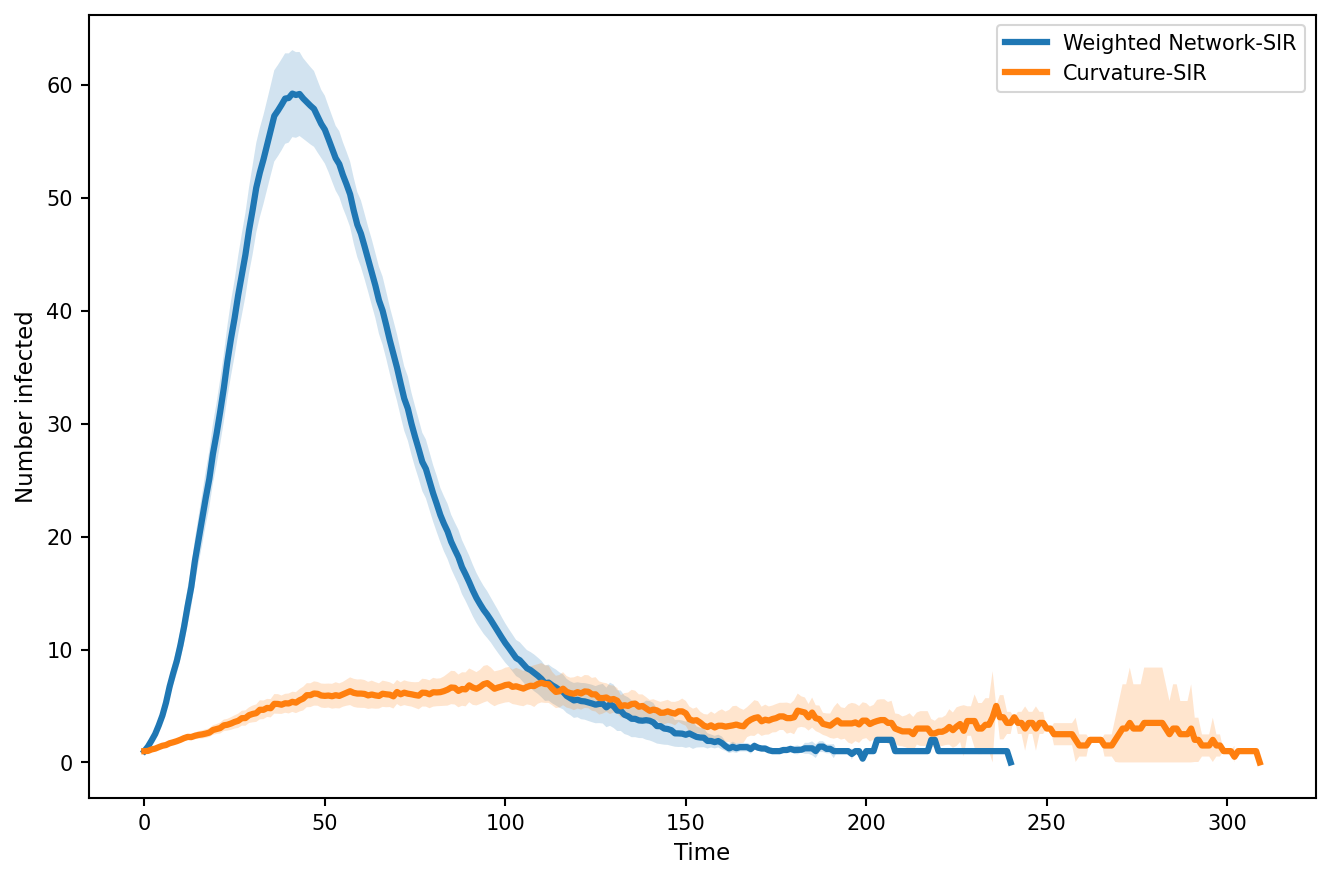

In [ ]:
# ============================================================
# PLOT — BASELINE VS CURVATURE-SIR WITH 95% CI
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

# ------------------------------------------------------------
# Define time axes from the trajectory lengths
# ------------------------------------------------------------

t_baseline = np.arange(len(baseline_mean))
t_curvature = np.arange(len(curvature_mean))

# ------------------------------------------------------------
# Baseline Weighted Network-SIR
# ------------------------------------------------------------

ax.plot(
    t_baseline,
    baseline_mean,
    linewidth=3,
    label="Weighted Network-SIR"
)

ax.fill_between(
    t_baseline,
    baseline_lower,
    baseline_upper,
    alpha=0.20
)

# ------------------------------------------------------------
# Curvature-SIR
# ------------------------------------------------------------

ax.plot(
    t_curvature,
    curvature_mean,
    linewidth=3,
    label="Curvature-SIR"
)

ax.fill_between(
    t_curvature,
    curvature_lower,
    curvature_upper,
    alpha=0.20
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Time"
)

ax.set_ylabel(
    "Number infected"
)

ax.legend()

# ------------------------------------------------------------
# BOXED AXES
# ------------------------------------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Baseline_vs_Curvature_CI.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

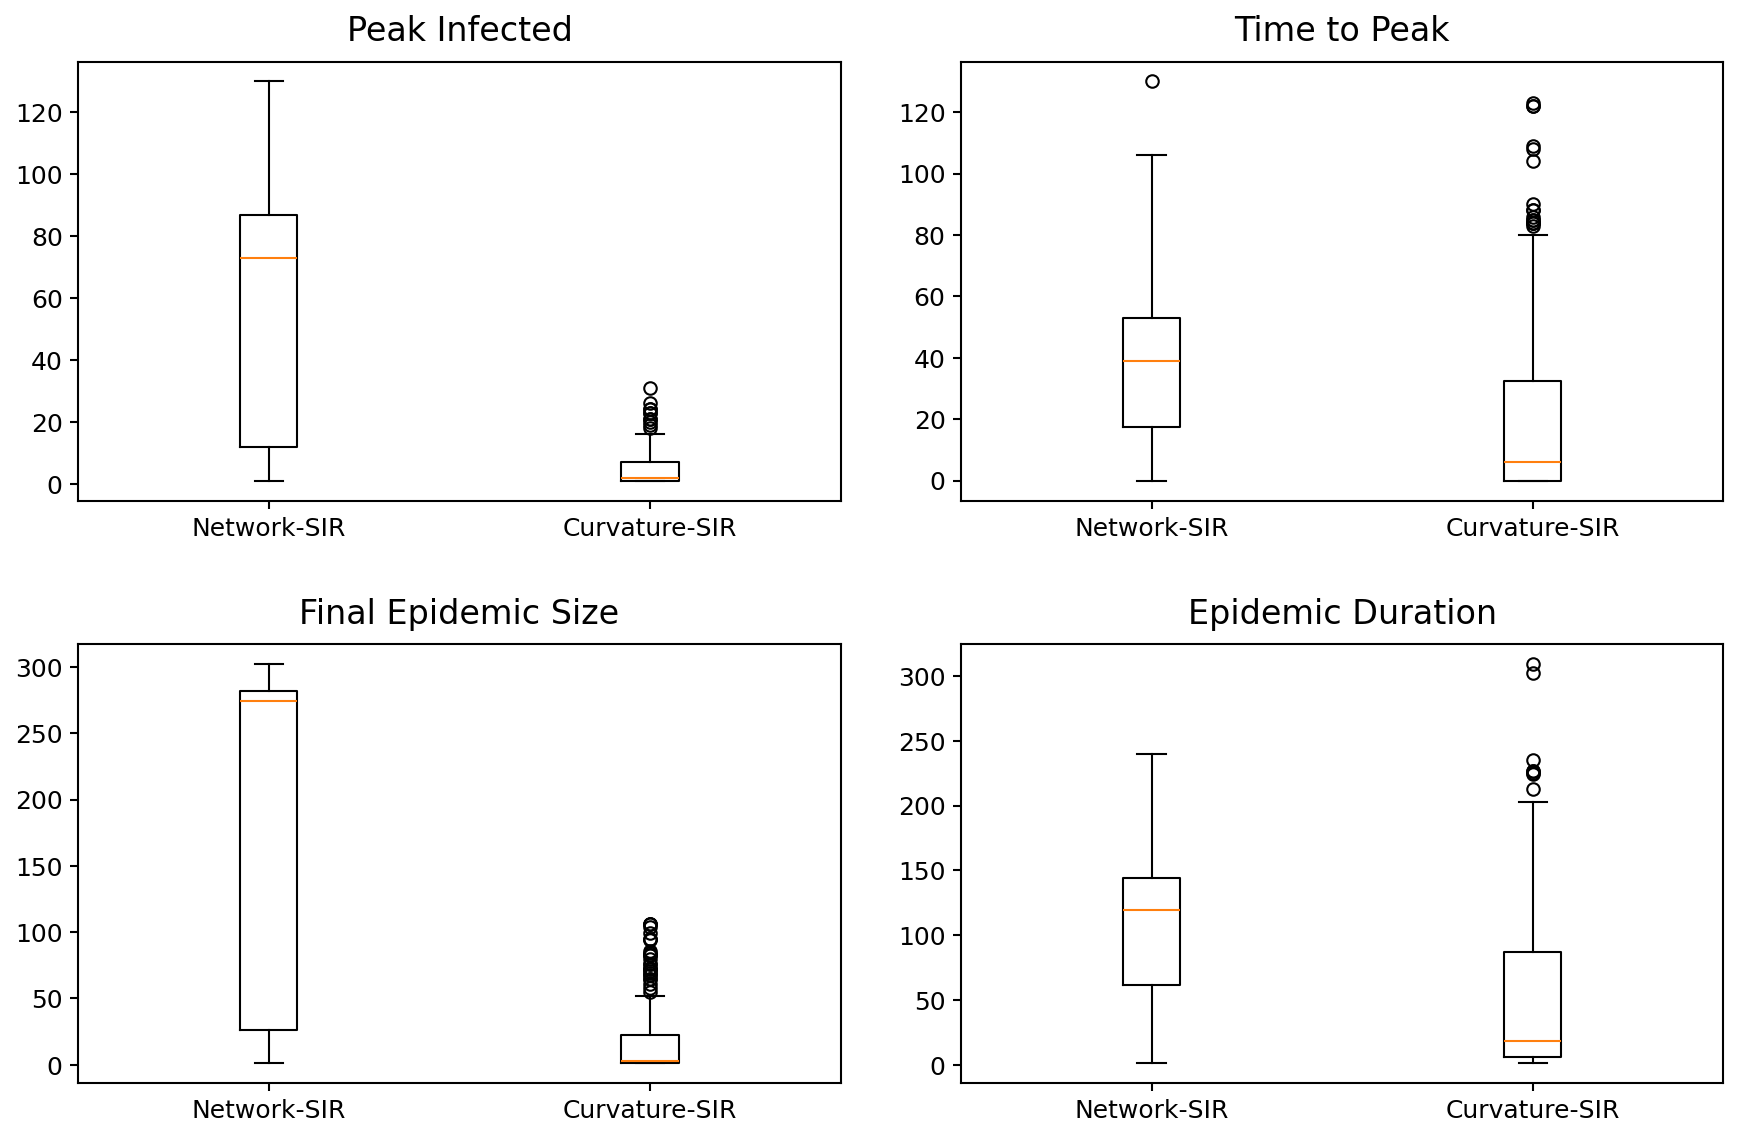

In [ ]:
# ============================================================
# STEP 6D.7
# BOXPLOT COMPARISON OF STOCHASTIC OUTCOMES
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    dpi=150
)

metrics = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

titles = [
    "Peak Infected",
    "Time to Peak",
    "Final Epidemic Size",
    "Epidemic Duration"
]

for ax, metric, title in zip(
    axes.flatten(),
    metrics,
    titles
):

    ax.boxplot(
        [
            baseline_runs["metrics"][metric],
            curvature_runs["metrics"][metric]
        ]
    )

    ax.set_xticks([1, 2])

    ax.set_xticklabels(
        [
            "Network-SIR",
            "Curvature-SIR"
        ],
        rotation=0
    )

    ax.set_title(
        title,
        fontsize=16,
        pad=10
    )

    #ax.grid(
     #   axis="y",
      #  alpha=0.3
    #)

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    # ------------------------------------------------------------
    # BOXED AXES (The Rectangle Effect for each subplot)
    # ------------------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    # Ensure ticks are drawn with consistent style
    ax.tick_params(
        direction="out",
        length=4,
        width=1.0,
        colors="black"
    )

plt.tight_layout(
    pad=2.0,
    w_pad=2.5,
    h_pad=2.5
)

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Boxplots.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6D.8
# MAPPING ROBUSTNESS WITH 95% CI
# ============================================================

mapping_results = []

for mapping_name, attr in E6_MAPPINGS.items():

    out = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr=attr,
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    stats = summarize_metric(
        out["metrics"]["Peak_Infected"]
    )

    mapping_results.append({

        "Mapping": mapping_name,
        **stats
    })

mapping_peak_df = pd.DataFrame(mapping_results)

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

means = mapping_peak_df["Mean"]

err_low = means - mapping_peak_df["CI95_Lower"]

err_high = mapping_peak_df["CI95_Upper"] - means

ax.bar(mapping_peak_df["Mapping"], means)

ax.errorbar(
    mapping_peak_df["Mapping"],
    means,
    yerr=[err_low, err_high],
    fmt='none',
    capsize=6
)

ax.set_ylabel("Peak Number of Infectious Students")

#ax.set_title(
#    "Peak Epidemic Size Across Curvature-Transmission Mappings\n"
#    "(Mean ± 95% CI)"
#)

#ax.grid(alpha=0.3)

# ------------------------------------------------------------
# BOXED AXES (The Rectangle Effect)
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Mapping_Robustness.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6D.9
# ALPHA SENSITIVITY WITH 95% CI
# ============================================================

alpha_summary = []

# Store the complete ensemble output for each alpha.
# This will also allow us to verify that alpha = 0
# exactly reproduces the baseline ensemble.
alpha_results = {}

for alpha in E6_ALPHA_GRID:

    print(
        f"\nRunning alpha = {alpha:.2f}"
    )

    # --------------------------------------------------------
    # Rebuild curvature-to-transmission mappings
    # for the current alpha value.
    # --------------------------------------------------------

    attach_e6_mapping_curvature(
        G,
        source_attr="curvature_std",
        alpha=float(alpha)
    )

    # --------------------------------------------------------
    # Run the existing stochastic SIR simulator through
    # the extended ensemble wrapper.
    # --------------------------------------------------------

    out = run_curvature_sir_ensemble_extended(
        G,
        beta0=E6_BETA0,
        gamma=E6_GAMMA,
        weight_attr=E6_WEIGHT_ATTR,
        curvature_attr="mapping_exponential",
        n_runs=E6_N_RUNS,
        seed0=E6_SEED0,
        max_steps=E6_MAX_STEPS
    )

    alpha_results[float(alpha)] = out

    metrics = out["metrics"]

    # --------------------------------------------------------
    # Check for truncated simulations
    # --------------------------------------------------------

    n_truncated = int(
        metrics["Hit_Max_Steps"].sum()
    )

    if n_truncated > 0:

        raise RuntimeError(
            f"Alpha = {alpha:.2f}: "
            f"{n_truncated} runs reached max_steps."
        )

    # --------------------------------------------------------
    # Statistical summaries
    # --------------------------------------------------------

    peak_stats = summarize_metric(
        metrics["Peak_Infected"]
    )

    peak_time_stats = summarize_metric(
        metrics["Peak_Time"]
    )

    final_size_stats = summarize_metric(
        metrics["Final_Size"]
    )

    duration_stats = summarize_metric(
        metrics["Duration"]
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    alpha_summary.append({

        "Network":
            "High-School",

        "Alpha":
            float(alpha),

        # Peak infected
        "Peak_Infected_Mean":
            peak_stats["Mean"],

        "Peak_Infected_SD":
            peak_stats["SD"],

        "Peak_Infected_CI95_Lower":
            peak_stats["CI95_Lower"],

        "Peak_Infected_CI95_Upper":
            peak_stats["CI95_Upper"],

        "Peak_Infected_Median":
            peak_stats["Median"],

        "Peak_Infected_IQR_Lower":
            peak_stats["IQR_Lower"],

        "Peak_Infected_IQR_Upper":
            peak_stats["IQR_Upper"],

        # Peak time
        "Peak_Time_Mean":
            peak_time_stats["Mean"],

        "Peak_Time_SD":
            peak_time_stats["SD"],

        "Peak_Time_CI95_Lower":
            peak_time_stats["CI95_Lower"],

        "Peak_Time_CI95_Upper":
            peak_time_stats["CI95_Upper"],

        "Peak_Time_Median":
            peak_time_stats["Median"],

        "Peak_Time_IQR_Lower":
            peak_time_stats["IQR_Lower"],

        "Peak_Time_IQR_Upper":
            peak_time_stats["IQR_Upper"],

        # Final epidemic size
        "Final_Size_Mean":
            final_size_stats["Mean"],

        "Final_Size_SD":
            final_size_stats["SD"],

        "Final_Size_CI95_Lower":
            final_size_stats["CI95_Lower"],

        "Final_Size_CI95_Upper":
            final_size_stats["CI95_Upper"],

        "Final_Size_Median":
            final_size_stats["Median"],

        "Final_Size_IQR_Lower":
            final_size_stats["IQR_Lower"],

        "Final_Size_IQR_Upper":
            final_size_stats["IQR_Upper"],

        # Duration
        "Duration_Mean":
            duration_stats["Mean"],

        "Duration_SD":
            duration_stats["SD"],

        "Duration_CI95_Lower":
            duration_stats["CI95_Lower"],

        "Duration_CI95_Upper":
            duration_stats["CI95_Upper"],

        "Duration_Median":
            duration_stats["Median"],

        "Duration_IQR_Lower":
            duration_stats["IQR_Lower"],

        "Duration_IQR_Upper":
            duration_stats["IQR_Upper"],

        "N":
            len(metrics)

    })


# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

alpha_summary_df = pd.DataFrame(
    alpha_summary
)

print("\nALPHA SENSITIVITY SUMMARY")
print("=" * 80)

display(
    alpha_summary_df.round(3)
)


Running alpha = 0.00

Running alpha = 0.25

Running alpha = 0.50

Running alpha = 0.75

Running alpha = 1.00

Running alpha = 1.50

Running alpha = 2.00

ALPHA SENSITIVITY SUMMARY


,Network,Alpha,Peak_Infected_Mean,Peak_Infected_SD,Peak_Infected_CI95_Lower,Peak_Infected_CI95_Upper,Peak_Infected_Median,Peak_Infected_IQR_Lower,Peak_Infected_IQR_Upper,Peak_Time_Mean,...,Final_Size_IQR_Lower,Final_Size_IQR_Upper,Duration_Mean,Duration_SD,Duration_CI95_Lower,Duration_CI95_Upper,Duration_Median,Duration_IQR_Lower,Duration_IQR_Upper,N
0,High-School,0.00,59.680,37.270,54.483,64.877,73.0,11.75,87.00,36.200,...,26.25,282.00,102.495,59.447,94.206,110.784,119.5,61.50,144.00,200
1,High-School,0.25,33.000,27.021,29.232,36.768,40.0,2.00,54.00,45.455,...,2.00,263.00,111.915,87.731,99.682,124.148,134.5,11.00,173.50,200
2,High-School,0.50,15.025,16.566,12.715,17.335,4.5,1.00,28.25,37.900,...,1.00,182.25,91.695,94.687,78.492,104.898,35.5,9.00,176.50,200
3,High-School,0.75,8.210,9.529,6.881,9.539,2.0,1.00,14.00,32.845,...,1.00,54.25,74.715,89.929,62.175,87.255,24.5,7.00,131.00,200
4,High-School,1.00,5.065,5.976,4.232,5.898,2.0,1.00,7.00,20.745,...,1.00,22.25,52.600,66.538,43.322,61.878,18.0,6.00,87.25,200
5,High-School,1.50,2.945,3.046,2.520,3.370,2.0,1.00,3.25,13.665,...,1.00,6.00,33.325,43.910,27.202,39.448,16.0,6.00,41.00,200
6,High-School,2.00,2.310,2.073,2.021,2.599,1.0,1.00,3.00,9.970,...,1.00,4.00,27.835,34.569,23.015,32.655,15.0,5.75,33.25,200


In [72]:
# ============================================================
# STEP 6.14 — ALPHA-RELATIVE EFFECTS
# ============================================================

alpha_baseline = (
    alpha_summary_df[
        alpha_summary_df["Alpha"] == 0.0
    ]
    .iloc[0]
)

alpha_effects = alpha_summary_df.copy()

alpha_effects["Peak_Change_Pct"] = (
    (
        alpha_effects["Peak_Infected_Mean"]
        - alpha_baseline["Peak_Infected_Mean"]
    )
    / alpha_baseline["Peak_Infected_Mean"]
    * 100
)

alpha_effects["Peak_Time_Change_Pct"] = (
    (
        alpha_effects["Peak_Time_Mean"]
        - alpha_baseline["Peak_Time_Mean"]
    )
    / alpha_baseline["Peak_Time_Mean"]
    * 100
)

alpha_effects["Final_Size_Change_Pct"] = (
    (
        alpha_effects["Final_Size_Mean"]
        - alpha_baseline["Final_Size_Mean"]
    )
    / alpha_baseline["Final_Size_Mean"]
    * 100
)

display(
    alpha_effects[
        [
            "Alpha",
            "Peak_Infected_Mean",
            "Peak_Change_Pct",
            "Peak_Time_Mean",
            "Peak_Time_Change_Pct",
            "Final_Size_Mean",
            "Final_Size_Change_Pct"
        ]
    ].round(3)
)

,Alpha,Peak_Infected_Mean,Peak_Change_Pct,Peak_Time_Mean,Peak_Time_Change_Pct,Final_Size_Mean,Final_Size_Change_Pct
0,0.00,59.680,0.000,36.200,0.000,202.995,0.000
1,0.25,33.000,-44.705,45.455,25.566,152.685,-24.784
2,0.50,15.025,-74.824,37.900,4.696,78.950,-61.107
3,0.75,8.210,-86.243,32.845,-9.268,38.050,-81.256
4,1.00,5.065,-91.513,20.745,-42.693,17.470,-91.394
5,1.50,2.945,-95.065,13.665,-62.251,6.685,-96.707
6,2.00,2.310,-96.129,9.970,-72.459,4.070,-97.995


In [73]:
# ============================================================
# STEP 6.14A — LINEAR MAPPING CLIPPING DIAGNOSTIC
# ============================================================
#
# Quantify the proportion of edges affected by positivity
# clipping under the linear curvature mapping:
#
#     g_linear(F) = max(epsilon, 1 + alpha * F_tilde)
#
# An edge is classified as clipped when:
#
#     1 + alpha * F_tilde <= epsilon
#
# This diagnostic is evaluated independently of the epidemic
# simulations so that clipping can be reported transparently.
# ============================================================

linear_clipping_diagnostic = []

# Curvature values used by the Experiment 6 mapping
F_std = np.array(
    [
        float(d.get("curvature_std", 0.0))
        for _, _, d in G.edges(data=True)
    ],
    dtype=float
)

n_edges = len(F_std)

if n_edges == 0:
    raise RuntimeError(
        "No edges were found in G for the clipping diagnostic."
    )


for alpha in E6_ALPHA_GRID:

    alpha = float(alpha)

    # Raw linear mapping before positivity clipping
    raw_linear = (
        1.0
        + alpha * F_std
    )

    # Edges whose raw value is at or below epsilon
    clipped_mask = (
        raw_linear <= E6_EPSILON
    )

    n_clipped = int(
        np.sum(clipped_mask)
    )

    clipping_percentage = (
        100.0 * n_clipped / n_edges
    )

    linear_clipping_diagnostic.append({
        "Network": "High-School",
        "Alpha": alpha,
        "Total_Edges": n_edges,
        "Clipped_Edges": n_clipped,
        "Clipped_Edge_Percentage": clipping_percentage,
        "Minimum_Raw_Linear_Mapping": float(
            np.min(raw_linear)
        ),
        "Maximum_Raw_Linear_Mapping": float(
            np.max(raw_linear)
        )
    })


linear_clipping_df = pd.DataFrame(
    linear_clipping_diagnostic
)


display(
    linear_clipping_df.round(4)
)

,Network,Alpha,Total_Edges,Clipped_Edges,Clipped_Edge_Percentage,Minimum_Raw_Linear_Mapping,Maximum_Raw_Linear_Mapping
0,High-School,0.00,5818,0,0.0000,1.0000,1.0000
1,High-School,0.25,5818,71,1.2204,-2.0802,1.1700
2,High-School,0.50,5818,255,4.3829,-5.1604,1.3399
3,High-School,0.75,5818,410,7.0471,-8.2407,1.5099
4,High-School,1.00,5818,525,9.0237,-11.3209,1.6799
5,High-School,1.50,5818,703,12.0832,-17.4813,2.0198
6,High-School,2.00,5818,840,14.4380,-23.6418,2.3597


In [74]:
# ============================================================
# STEP 6.14B — LINEAR CLIPPING REPORT AT ALPHA = 1
# ============================================================

alpha1_clipping = linear_clipping_df[
    np.isclose(
        linear_clipping_df["Alpha"],
        1.0
    )
].iloc[0]

print(
    "LINEAR MAPPING CLIPPING AT ALPHA = 1"
)
print("=" * 60)

print(
    f"Total edges       : "
    f"{int(alpha1_clipping['Total_Edges'])}"
)

print(
    f"Clipped edges     : "
    f"{int(alpha1_clipping['Clipped_Edges'])}"
)

print(
    f"Clipped edges (%) : "
    f"{alpha1_clipping['Clipped_Edge_Percentage']:.2f}%"
)

LINEAR MAPPING CLIPPING AT ALPHA = 1
Total edges       : 5818
Clipped edges     : 525
Clipped edges (%) : 9.02%


In [75]:
# ------------------------------------------------------------
# Save clipping diagnostic
# ------------------------------------------------------------

linear_clipping_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_linear_clipping_diagnostic.csv"
    ),
    index=False
)

print(
    "Saved:",
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_linear_clipping_diagnostic.csv"
    )
)

Saved: experiment6_results/experiment6d_linear_clipping_diagnostic.csv


In [76]:
# ============================================================
# STEP 6.15 — VERIFY ALPHA = 0 BASELINE RECOVERY
# ============================================================

alpha0_metrics = alpha_results[0.0]["metrics"]
baseline_metrics = baseline_runs["metrics"]

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

print("ALPHA = 0 BASELINE RECOVERY CHECK")
print("=" * 60)

all_passed = True

for metric in metrics_to_check:

    alpha0_values = alpha0_metrics[metric].to_numpy()
    baseline_values = baseline_metrics[metric].to_numpy()

    passed = np.array_equal(
        alpha0_values,
        baseline_values
    )

    max_difference = np.max(
        np.abs(alpha0_values - baseline_values)
    )

    print(
        f"{metric:15s} : "
        f"{'PASS' if passed else 'FAIL'} "
        f"(max difference = {max_difference:.6g})"
    )

    if not passed:
        all_passed = False

if not all_passed:
    raise RuntimeError(
        "Alpha = 0 does not exactly reproduce the baseline ensemble."
    )

print(
    "✓ Alpha = 0 exactly reproduces the baseline ensemble."
)

ALPHA = 0 BASELINE RECOVERY CHECK
Peak_Infected   : PASS (max difference = 0)
Peak_Time       : PASS (max difference = 0)
Final_Size      : PASS (max difference = 0)
Duration        : PASS (max difference = 0)
✓ Alpha = 0 exactly reproduces the baseline ensemble.


In [77]:
# ============================================================
# STEP 6.15A — VERIFY ALPHA = 1 TABLE 6 CONSISTENCY
# ============================================================

# The alpha = 1 result from the sensitivity experiment must
# reproduce the principal Curvature-SIR ensemble used for
# Table 6 because both use the same:
#
#   - network
#   - beta0
#   - gamma
#   - edge weights
#   - alpha
#   - random seeds
#   - mean-normalised exponential mapping

alpha1_metrics = alpha_results[
    float(E6_ALPHA_MAIN)
]["metrics"]

table6_curvature_metrics = (
    curvature_runs["metrics"]
)

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

print(
    "ALPHA = 1 TABLE 6 CONSISTENCY CHECK"
)
print("=" * 60)

all_passed = True

for metric in metrics_to_check:

    alpha1_values = (
        alpha1_metrics[metric]
        .to_numpy()
    )

    table6_values = (
        table6_curvature_metrics[metric]
        .to_numpy()
    )

    passed = np.array_equal(
        alpha1_values,
        table6_values
    )

    max_difference = np.max(
        np.abs(
            alpha1_values -
            table6_values
        )
    )

    print(
        f"{metric:15s}: "
        f"{'PASS' if passed else 'FAIL'} "
        f"(max difference = "
        f"{max_difference:.6g})"
    )

    if not passed:
        all_passed = False

if not all_passed:

    raise RuntimeError(
        "The alpha = 1 sensitivity ensemble "
        "does not exactly reproduce the "
        "Table 6 curvature ensemble."
    )

print(
    "✓ Alpha = 1 exactly reproduces the "
    "Table 6 Curvature-SIR ensemble."
)

ALPHA = 1 TABLE 6 CONSISTENCY CHECK
Peak_Infected  : PASS (max difference = 0)
Peak_Time      : PASS (max difference = 0)
Final_Size     : PASS (max difference = 0)
Duration       : PASS (max difference = 0)
✓ Alpha = 1 exactly reproduces the Table 6 Curvature-SIR ensemble.


In [78]:
print(alpha_summary_df.columns.tolist())

['Network', 'Alpha', 'Peak_Infected_Mean', 'Peak_Infected_SD', 'Peak_Infected_CI95_Lower', 'Peak_Infected_CI95_Upper', 'Peak_Infected_Median', 'Peak_Infected_IQR_Lower', 'Peak_Infected_IQR_Upper', 'Peak_Time_Mean', 'Peak_Time_SD', 'Peak_Time_CI95_Lower', 'Peak_Time_CI95_Upper', 'Peak_Time_Median', 'Peak_Time_IQR_Lower', 'Peak_Time_IQR_Upper', 'Final_Size_Mean', 'Final_Size_SD', 'Final_Size_CI95_Lower', 'Final_Size_CI95_Upper', 'Final_Size_Median', 'Final_Size_IQR_Lower', 'Final_Size_IQR_Upper', 'Duration_Mean', 'Duration_SD', 'Duration_CI95_Lower', 'Duration_CI95_Upper', 'Duration_Median', 'Duration_IQR_Lower', 'Duration_IQR_Upper', 'N']


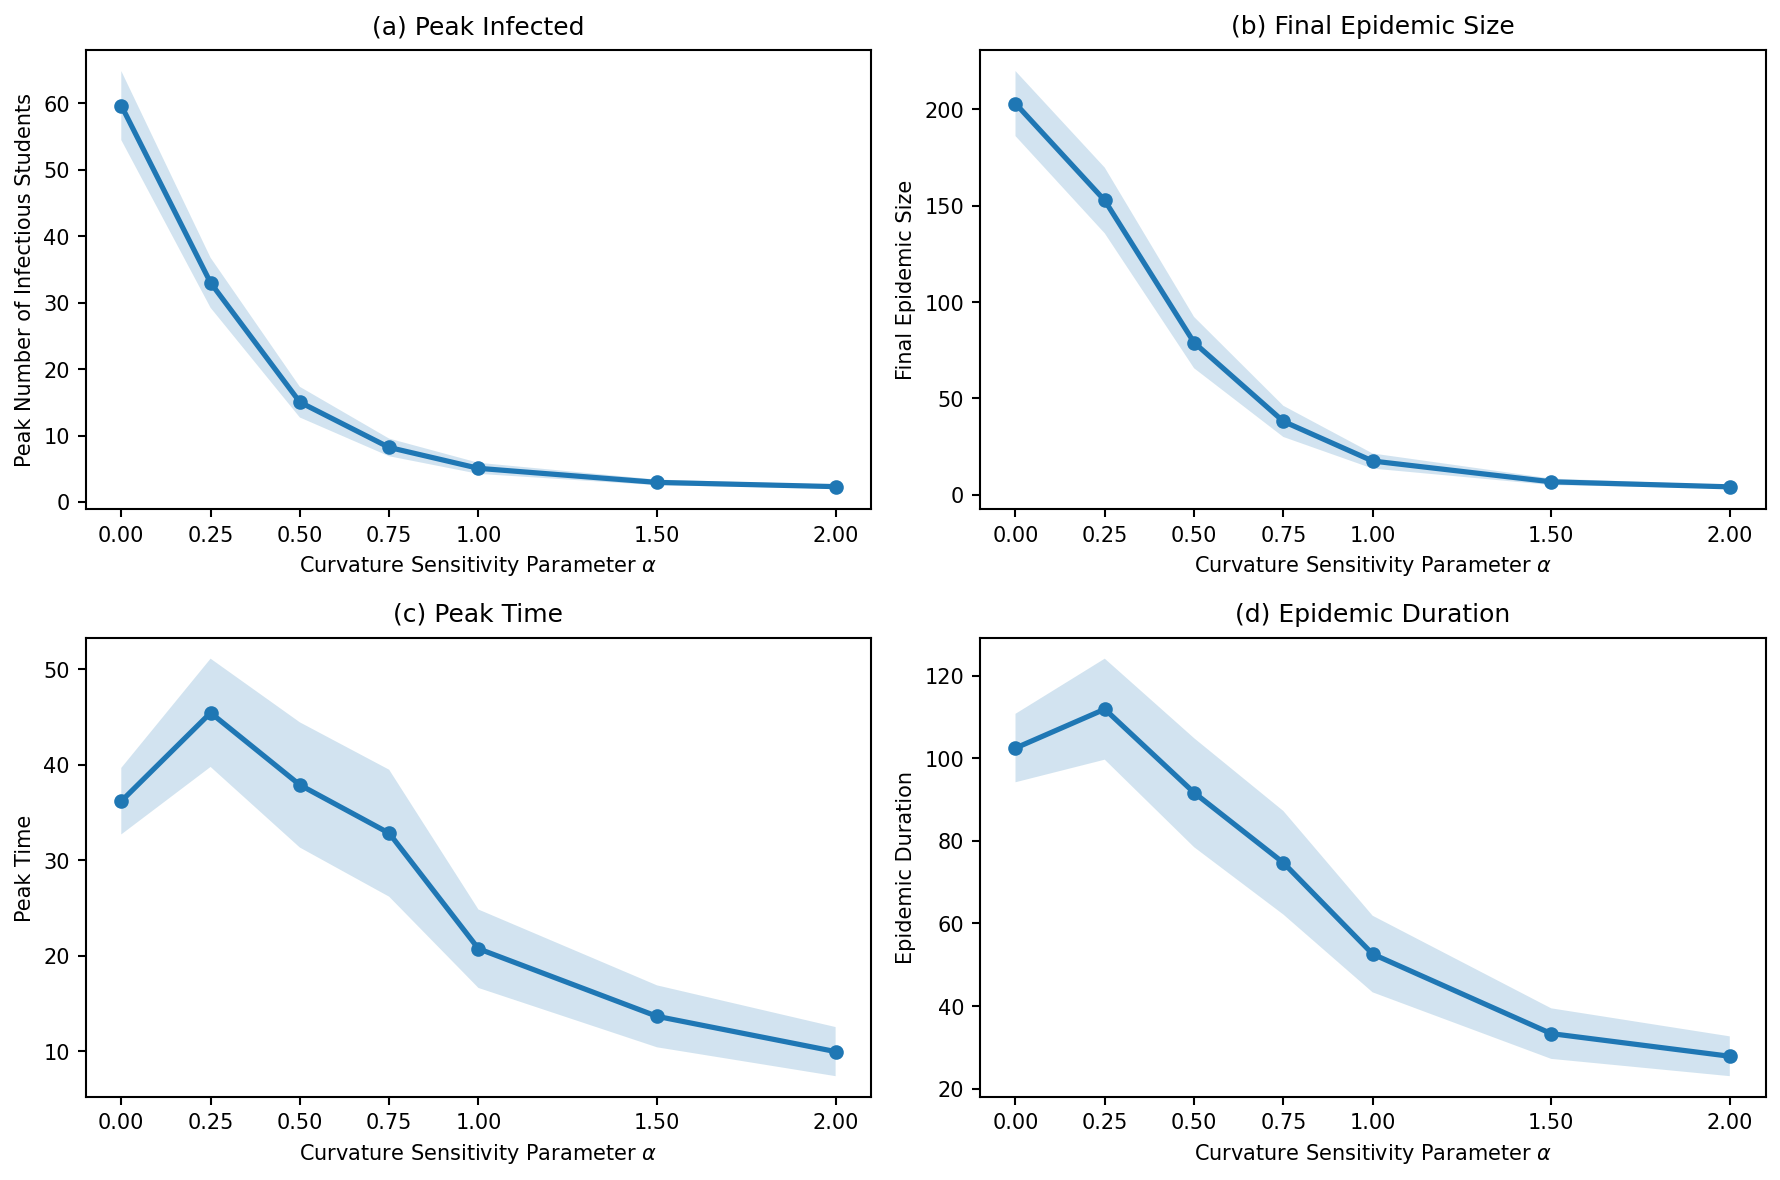

In [79]:
# ============================================================
# FIGURE E6 — ALPHA SENSITIVITY OF EPIDEMIC OUTCOMES
# ============================================================

# ------------------------------------------------------------
# Create 2 × 2 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    dpi=150
)

axes = axes.flatten()

# ------------------------------------------------------------
# Define metrics
# ------------------------------------------------------------

metrics = [
    {
        "mean": "Peak_Infected_Mean",
        "lower": "Peak_Infected_CI95_Lower",
        "upper": "Peak_Infected_CI95_Upper",
        "ylabel": "Peak Number of Infectious Students",
        "title": "(a) Peak Infected"
    },
    {
        "mean": "Final_Size_Mean",
        "lower": "Final_Size_CI95_Lower",
        "upper": "Final_Size_CI95_Upper",
        "ylabel": "Final Epidemic Size",
        "title": "(b) Final Epidemic Size"
    },
    {
        "mean": "Peak_Time_Mean",
        "lower": "Peak_Time_CI95_Lower",
        "upper": "Peak_Time_CI95_Upper",
        "ylabel": "Peak Time",
        "title": "(c) Peak Time"
    },
    {
        "mean": "Duration_Mean",
        "lower": "Duration_CI95_Lower",
        "upper": "Duration_CI95_Upper",
        "ylabel": "Epidemic Duration",
        "title": "(d) Epidemic Duration"
    }
]

# ------------------------------------------------------------
# Plot each metric
# ------------------------------------------------------------

for ax, metric in zip(axes, metrics):

    x = alpha_summary_df["Alpha"]

    mean = alpha_summary_df[metric["mean"]]
    lower = alpha_summary_df[metric["lower"]]
    upper = alpha_summary_df[metric["upper"]]

    # Mean trajectory
    ax.plot(
        x,
        mean,
        marker="o",
        linewidth=2.5,
        markersize=6
    )

    # 95% confidence interval
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.20
    )

    # Panel title
    ax.set_title(
        metric["title"],
        fontsize=12,
        pad=8
    )

    # Axis labels
    ax.set_xlabel(
        r"Curvature Sensitivity Parameter $\alpha$",
        fontsize=10
    )

    ax.set_ylabel(
        metric["ylabel"],
        fontsize=10
    )

    # Grid
    #ax.grid(alpha=0.3)

    # Ensure all alpha values are displayed
    ax.set_xticks(
        alpha_summary_df["Alpha"]
    )

    # ------------------------------------------------------------
    # BOXED AXES (The Rectangle Effect for each subplot)
    # ------------------------------------------------------------
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.tick_params(
        direction="out",
        length=4,
        width=1.0,
        colors="black"
    )

# ------------------------------------------------------------
# Overall figure layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Alpha_Sensitivity.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [80]:
# ============================================================
# RESTORE MAIN CURVATURE MAPPING
# ============================================================

attach_e6_mapping_curvature(
    G,
    source_attr="curvature_std",
    alpha=float(E6_ALPHA_MAIN)
)

print(
    f"Curvature mappings restored to alpha = "
    f"{E6_ALPHA_MAIN:.2f}"
)

Curvature mappings restored to alpha = 1.00


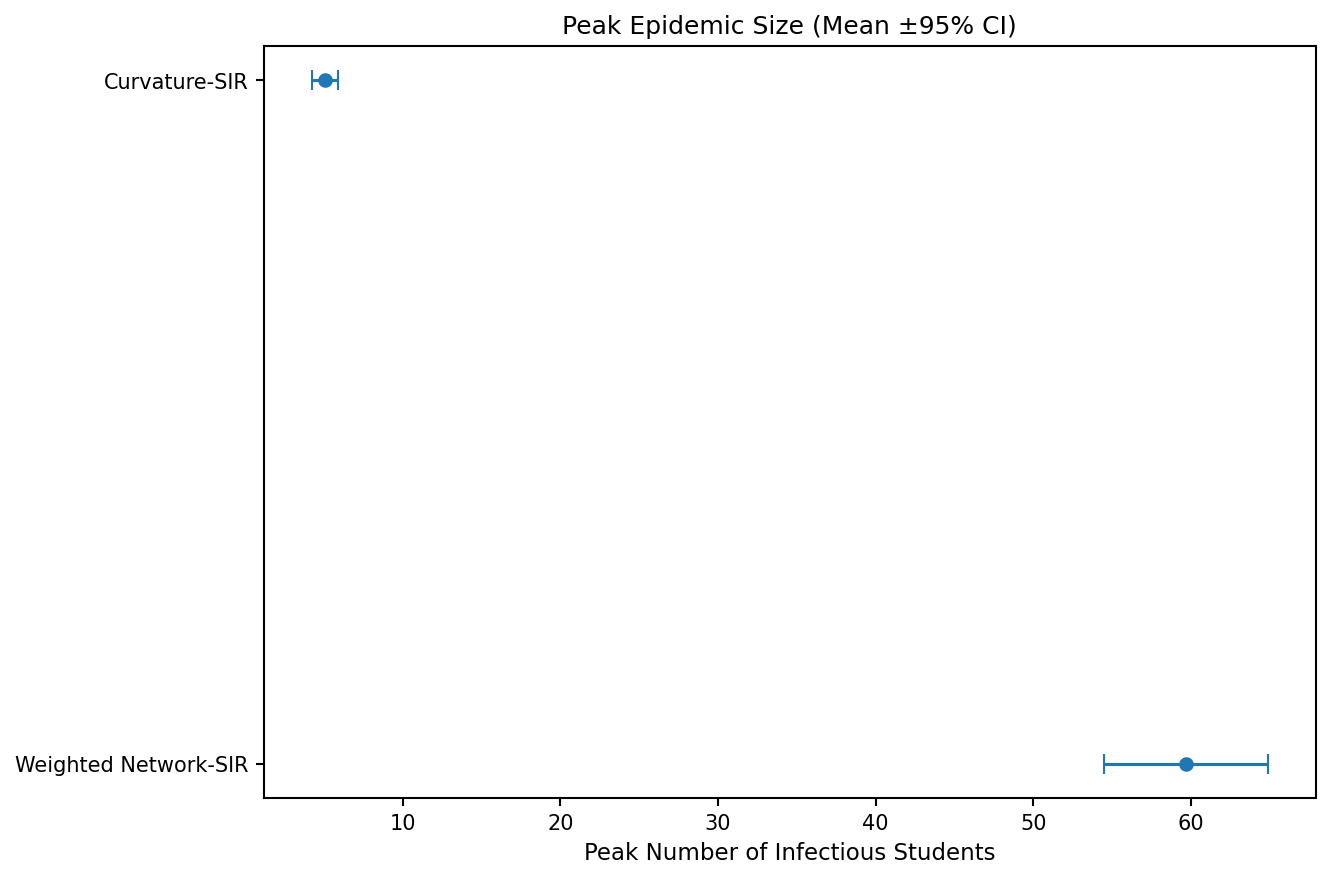

In [81]:
# ============================================================
# STEP 6D.10
# FOREST PLOT OF ALL METRICS
# ============================================================

forest = summary_table[
    summary_table["Metric"] == "Peak_Infected"
]

fig, ax = plt.subplots(
    figsize=(9, 6),
    dpi=150
)

y = np.arange(len(forest))

means = forest["Mean"]

lower = forest["CI95_Lower"]

upper = forest["CI95_Upper"]

ax.errorbar(
    means,
    y,
    xerr=[means - lower, upper - means],
    fmt='o',
    capsize=5
)

ax.set_yticks(y)

ax.set_yticklabels(forest["Model"])

ax.set_xlabel("Peak Number of Infectious Students")

ax.set_title("Peak Epidemic Size (Mean ±95% CI)")

#ax.grid(alpha=0.3)

# ------------------------------------------------------------
# BOXED AXES (The Rectangle Effect)
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    direction="out",
    length=4,
    width=1.0,
    colors="black"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        E6_OUTPUT_DIR,
        "Figure_E6_Forest.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [82]:
# ============================================================
# STEP 6D.11
# EXPORT ALL STATISTICAL TABLES
# ============================================================

mapping_peak_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_mapping_peak_summary.csv"
    ),
    index=False
)

alpha_summary_df.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_alpha_summary.csv"
    ),
    index=False
)

summary_table.to_csv(
    os.path.join(
        E6_OUTPUT_DIR,
        "experiment6d_full_summary.csv"
    ),
    index=False
)

print("Experiment 6D exported successfully.")

Experiment 6D exported successfully.


In [83]:
# ============================================================
# STEP 6.18 — EXPERIMENT 6 DIAGNOSTIC REPORT
# ============================================================

print("=" * 60)
print("EXPERIMENT 6 DIAGNOSTIC REPORT")
print("=" * 60)

print("\nNETWORK")
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

print("\nCURVATURE")
print("Raw mean :", e6_F_mean)
print("Raw SD   :", e6_F_sd)

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

baseline_metrics = baseline_runs["metrics"]

print("\nBASELINE — WEIGHTED NETWORK-SIR")

print(
    "Peak I       :",
    baseline_metrics["Peak_Infected"].mean()
)

print(
    "Peak time    :",
    baseline_metrics["Peak_Time"].mean()
)

print(
    "Final size   :",
    baseline_metrics["Final_Size"].mean()
)

# ------------------------------------------------------------
# CURVATURE-SIR
# ------------------------------------------------------------

curvature_metrics = curvature_runs["metrics"]

print("\nCURVATURE-SIR")

print(
    "Peak I       :",
    curvature_metrics["Peak_Infected"].mean()
)

print(
    "Peak time    :",
    curvature_metrics["Peak_Time"].mean()
)

print(
    "Final size   :",
    curvature_metrics["Final_Size"].mean()
)

# ------------------------------------------------------------
# MAPPING CHECK
# ------------------------------------------------------------

print("\nMAPPING CHECK")

print(
    e6_mapping_check[
        [
            "Mapping",
            "Mean",
            "SD",
            "Min",
            "Max"
        ]
    ]
)

# ------------------------------------------------------------
# ALPHA = 0 BASELINE RECOVERY
# ------------------------------------------------------------

print("\nALPHA = 0 BASELINE CHECK")

alpha0_metrics = alpha_results[0.0]["metrics"]

metrics_to_check = [
    "Peak_Infected",
    "Peak_Time",
    "Final_Size",
    "Duration"
]

for metric in metrics_to_check:

    alpha0_values = alpha0_metrics[metric].to_numpy()
    baseline_values = baseline_metrics[metric].to_numpy()

    max_difference = np.max(
        np.abs(alpha0_values - baseline_values)
    )

    print(
        f"{metric:15s}: "
        f"max difference = {max_difference:.6g}"
    )

print("\n" + "=" * 60)
print("EXPERIMENT 6 COMPLETE")
print("=" * 60)

EXPERIMENT 6 DIAGNOSTIC REPORT

NETWORK
Nodes : 327
Edges : 5818

CURVATURE
Raw mean : -154.28290600754212
Raw SD   : 212.52337017444597

BASELINE — WEIGHTED NETWORK-SIR
Peak I       : 59.68
Peak time    : 36.2
Final size   : 202.995

CURVATURE-SIR
Peak I       : 5.065
Peak time    : 20.745
Final size   : 17.47

MAPPING CHECK
                     Mapping  Mean        SD           Min       Max
0      mapping_uniform_value   1.0  0.000000  1.000000e+00  1.000000
1       mapping_linear_value   1.0  0.432716  8.798175e-07  1.477973
2  mapping_exponential_value   1.0  0.401595  3.581820e-06  1.585846
3   mapping_saturating_value   1.0  0.400320  3.518298e-11  1.408913

ALPHA = 0 BASELINE CHECK
Peak_Infected  : max difference = 0
Peak_Time      : max difference = 0
Final_Size     : max difference = 0
Duration       : max difference = 0

EXPERIMENT 6 COMPLETE
